# Forecasting Prevalensi Ketidakcukupan Konsumsi Pangan (PoU) 2026-2028
## Kepulauan Maluku -- Model XGBoost Panel, Analisis Paradoks Produksi dan Underdog Ketahanan Pangan

**GEMASTIK XIX/2026 - Divisi Penambangan Data (Data Mining)**

Wilayah studi: 21 Kabupaten/Kota, Provinsi Maluku dan Maluku Utara. Data historis 2020-2025 (6 tahun),
forecast 2026-2028 (3 tahun ke depan).

Notebook ini fokus pada satu model forecasting utama -- **XGBoost berbasis panel data** -- yang dipilih
lewat perbandingan singkat dengan ElasticNet, lalu digali semaksimal mungkin: bukan hanya angka forecast,
tapi juga **apa yang mendorong prediksi tersebut** (feature importance), **kabupaten/kota mana yang
diproyeksikan berubah paling drastis**, dan dua analisis tematik:

- **Paradoks Produksi**: kabupaten/kota dengan kapasitas produksi pangan lokal (perikanan) tinggi namun PoU
  tetap tinggi -- bukti kuantitatif dari hipotesis "paradoks distribusi".
- **Underdog Ketahanan Pangan**: kabupaten/kota dengan kapasitas produksi rendah namun berhasil menekan PoU
  jauh di bawah yang diprediksikan kapasitasnya -- kandidat praktik baik (best practice) untuk direplikasi.

Alur notebook:

1. Persiapan lingkungan dan pemuatan data
2. EDA deret waktu sebelum forecasting
3. Praproses dan rekayasa fitur (termasuk *target encoding* karakteristik dasar tiap kabupaten/kota)
4. Pemilihan model: XGBoost vs ElasticNet lewat backtesting rekursif
5. Forecast final 2026-2028 dengan interval kepercayaan, per kabupaten/kota (dijamin tidak flat/seragam)
6. Insight model: apa yang mendorong prediksi PoU (feature importance)
7. Analisis Paradoks Produksi dan Underdog Ketahanan Pangan
8. Visualisasi utama: Top-1, Bottom-1, Paradoks, Underdog (historis + forecast dalam satu grafik)
9. Insight tambahan: pergerakan terbesar, agregat provinsi, kesenjangan target nasional, peta forecast 2028
10. Sintesis, dokumen RAG, dan ekspor hasil

In [2]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn scipy geopandas shapely xgboost
print("Instalasi selesai.")

Instalasi selesai.


## 1. Persiapan Lingkungan

In [3]:
import os
import io
import json
import zipfile
import warnings
import difflib
import urllib.parse

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titleweight"] = "bold"

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

OUTPUT_DIR = "gemastik_forecast_output"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
TABLE_DIR = os.path.join(OUTPUT_DIR, "tables")
for d in [OUTPUT_DIR, FIG_DIR, TABLE_DIR]:
    os.makedirs(d, exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

HISTORICAL_YEARS = [2020, 2021, 2022, 2023, 2024, 2025]
FORECAST_YEARS = [2026, 2027, 2028]

print("Lingkungan Colab:", IN_COLAB)
print("Direktori output:", os.path.abspath(OUTPUT_DIR))
print("Tahun historis:", HISTORICAL_YEARS)
print("Tahun forecast:", FORECAST_YEARS)

Lingkungan Colab: True
Direktori output: /content/gemastik_forecast_output
Tahun historis: [2020, 2021, 2022, 2023, 2024, 2025]
Tahun forecast: [2026, 2027, 2028]


## 2. Pemuatan Dataset

In [4]:
DEFAULT_FILENAME = "Untitled_spreadsheet_-_Data_Tabular.csv"

def locate_or_upload_dataset(default_name=DEFAULT_FILENAME):
    if os.path.exists(default_name):
        return default_name
    candidates = [f for f in os.listdir(".") if f.lower().endswith(".csv")]
    if candidates:
        return candidates[0]
    if IN_COLAB:
        from google.colab import files
        print("File dataset tidak ditemukan di direktori kerja. Silakan unggah file CSV dataset.")
        uploaded = files.upload()
        return list(uploaded.keys())[0]
    raise FileNotFoundError(
        "Dataset tidak ditemukan. Letakkan file CSV di direktori kerja notebook "
        "atau unggah manual melalui panel file Colab."
    )

DATA_PATH = locate_or_upload_dataset()
print("Menggunakan file dataset:", DATA_PATH)

df_raw = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
print("Dimensi data awal:", df_raw.shape)
df_raw.head(5)

Menggunakan file dataset: Untitled spreadsheet - Data Tabular.csv
Dimensi data awal: (126, 29)


,Provinsi,Kab/Kota,Tahun,Y_PoU (Persen),X1_Produksi_Perikanan_Tangkap_Laut (Ton),X2_Produksi_Padi (Ton),X4_NTP (Indeks),X5_Persentase_Penduduk_Miskin (Persen),X6_Garis_Kemiskinan (Rp/Kapita/Bulan),X7_Gini_Rasio (Indeks),...,X15_Rata_Rata_Lama_Sekolah (Tahun),X16_Rasio_Non_Angkatan_Kerja (Persen),X17_TPT (Persen),X18_Tenaga_Kerja_Pertanian_Kehutanan_Perikanan (Persen),X19_RT_Akses_Air_Minum_Layak (Persen),X20_RT_Akses_Sanitasi_Layak (Persen),X21_Prevalensi_Balita_Stunting (Persen),X22_UHH_Saat_Lahir (Tahun),X23_IPM (Indeks),X24_Persen_Desa_Sinyal_4G5G (Persen)
0,Maluku,Kepulauan Tanimbar (Maluku Tenggara Barat),2020,37.05,11616,174.64,96.77,27.11,479402,303.0,...,9.68,27.61,4.51,33.97,NaN,75.06,NaN,69.68,65.75,51.19
1,Maluku,Maluku Tenggara,2020,36.42,94908,8.33,96.77,22.57,517821,245.0,...,9.73,34.76,4.95,33.97,NaN,75.06,NaN,70.08,68.57,47.13
2,Maluku,Maluku Tengah,2020,43.07,155337,50374.78,96.77,19.83,503800,303.0,...,9.67,40.21,7.93,33.97,NaN,75.06,NaN,70.34,73.20,62.84
3,Maluku,Buru,2020,39.15,8277,45914.31,96.77,16.64,492055,294.0,...,8.52,28.31,6.28,33.97,NaN,75.06,NaN,69.70,70.55,68.42
4,Maluku,Kepulauan Aru,2020,40.42,91002,0.00,96.77,26.26,490565,316.0,...,8.82,30.60,3.83,33.97,NaN,75.06,NaN,69.58,66.88,54.31


## 3. Praproses Data

Perbaikan format angka pada `X1_Produksi_Perikanan_Tangkap_Laut` (campuran pemisah ribuan/desimal format
Indonesia pada 2023-2024, diverifikasi lewat kontinuitas deret waktu), penyederhanaan nama kolom, dan
imputasi bertahap (interpolasi internal per kabupaten/kota, forward/backward-fill, lalu KNN Imputer
lintas-kabupaten untuk sisa nilai kosong) -- tanpa mengisi nol pada data yang secara struktural tidak
tersedia.

In [5]:
def parse_id_number(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s == "":
        return np.nan
    parts = s.split(".")
    if len(parts) == 1:
        return float(parts[0])
    return float("".join(parts[:-1]) + "." + parts[-1])

df = df_raw.copy()
df["X1_Produksi_Perikanan_Tangkap_Laut (Ton)"] = (
    df["X1_Produksi_Perikanan_Tangkap_Laut (Ton)"].apply(parse_id_number)
)

rename_map = {
    "Y_PoU (Persen)": "Y_PoU",
    "X1_Produksi_Perikanan_Tangkap_Laut (Ton)": "X1_Perikanan",
    "X2_Produksi_Padi (Ton)": "X2_Padi",
    "X4_NTP (Indeks)": "X4_NTP",
    "X5_Persentase_Penduduk_Miskin (Persen)": "X5_PendudukMiskin",
    "X6_Garis_Kemiskinan (Rp/Kapita/Bulan)": "X6_GarisKemiskinan",
    "X7_Gini_Rasio (Indeks)": "X7_Gini",
    "X8_PDRB_per_Kapita_ADHB (Juta Rp)": "X8_PDRB",
    "X9_Pangsa_Pengeluaran_Pangan (Persen)": "X9_PangsaPangan",
    "X10_Rata_Rata_Pengeluaran_Pangan (Juta Rp/Kapita/Bulan)": "X10_PengeluaranPangan",
    "X11_Persentase_Jalan_Kondisi_Mantap (Persen)": "X11_JalanMantap",
    "X12_Kepadatan_Penduduk (Jiwa/Km\u00b2)": "X12_Kepadatan",
    "X13_Jumlah_Pelabuhan_Utama (Unit)": "X13a_Pelabuhan",
    "X13_Kunjungan_Kapal_Tahunan (Unit)": "X13b_KunjunganKapal",
    "X13_Jarak_ke_Pelabuhan_Induk (Km)": "X13c_JarakPelabuhan",
    "X14_TPAK (Persen)": "X14_TPAK",
    "X15_Rata_Rata_Lama_Sekolah (Tahun)": "X15_RLS",
    "X16_Rasio_Non_Angkatan_Kerja (Persen)": "X16_NonAK",
    "X17_TPT (Persen)": "X17_TPT",
    "X18_Tenaga_Kerja_Pertanian_Kehutanan_Perikanan (Persen)": "X18_TKPertanian",
    "X19_RT_Akses_Air_Minum_Layak (Persen)": "X19_AirMinum",
    "X20_RT_Akses_Sanitasi_Layak (Persen)": "X20_Sanitasi",
    "X21_Prevalensi_Balita_Stunting (Persen)": "X21_Stunting",
    "X22_UHH_Saat_Lahir (Tahun)": "X22_UHH",
    "X23_IPM (Indeks)": "X23_IPM",
    "X24_Persen_Desa_Sinyal_4G5G (Persen)": "X24_Sinyal4G5G",
}
df = df.rename(columns=rename_map)
df = df.sort_values(["Kab/Kota", "Tahun"]).reset_index(drop=True)

id_cols = ["Provinsi", "Kab/Kota", "Tahun"]
numeric_cols = [c for c in df.columns if c not in id_cols]

for c in numeric_cols:
    df[c] = df.groupby("Kab/Kota")[c].transform(
        lambda s: s.interpolate(method="linear", limit_area="inside").ffill().bfill()
    )

from sklearn.impute import KNNImputer
for c in numeric_cols:
    if df[c].isna().sum() == 0:
        continue
    for tahun in sorted(df["Tahun"].unique()):
        mask = df["Tahun"] == tahun
        if df.loc[mask, c].isna().sum() > 0 and df.loc[mask, c].notna().sum() >= 3:
            sub = df.loc[mask, numeric_cols].copy()
            imputer = KNNImputer(n_neighbors=3)
            imputed_values = imputer.fit_transform(sub)
            df.loc[mask, c] = imputed_values[:, numeric_cols.index(c)]

print("Sisa nilai kosong setelah praproses:", df[numeric_cols].isna().sum().sum())
kab_list = sorted(df["Kab/Kota"].unique())
print("Jumlah kabupaten/kota:", len(kab_list))
df.to_csv(os.path.join(TABLE_DIR, "dataset_bersih_forecasting.csv"), index=False, encoding="utf-8-sig")
df.head(3)

Sisa nilai kosong setelah praproses: 0
Jumlah kabupaten/kota: 21


,Provinsi,Kab/Kota,Tahun,Y_PoU,X1_Perikanan,X2_Padi,X4_NTP,X5_PendudukMiskin,X6_GarisKemiskinan,X7_Gini,...,X15_RLS,X16_NonAK,X17_TPT,X18_TKPertanian,X19_AirMinum,X20_Sanitasi,X21_Stunting,X22_UHH,X23_IPM,X24_Sinyal4G5G
0,Maluku,Buru,2020,39.15,8277.0,45914.31,96.77,16.64,492055,294.0,...,8.52,28.31,6.28,33.97,93.21,75.06,31.7,69.70,70.55,68.420000
1,Maluku,Buru,2021,30.87,11090.0,60572.67,101.14,17.28,503254,289.0,...,8.79,29.18,4.85,32.64,93.21,76.77,31.7,69.73,70.93,77.920000
2,Maluku,Buru,2022,34.38,12287.0,45450.84,104.85,15.82,530858,272.0,...,8.99,27.96,4.99,33.54,92.10,76.47,23.3,69.95,71.52,82.433333


## 4. EDA Deret Waktu Sebelum Forecasting

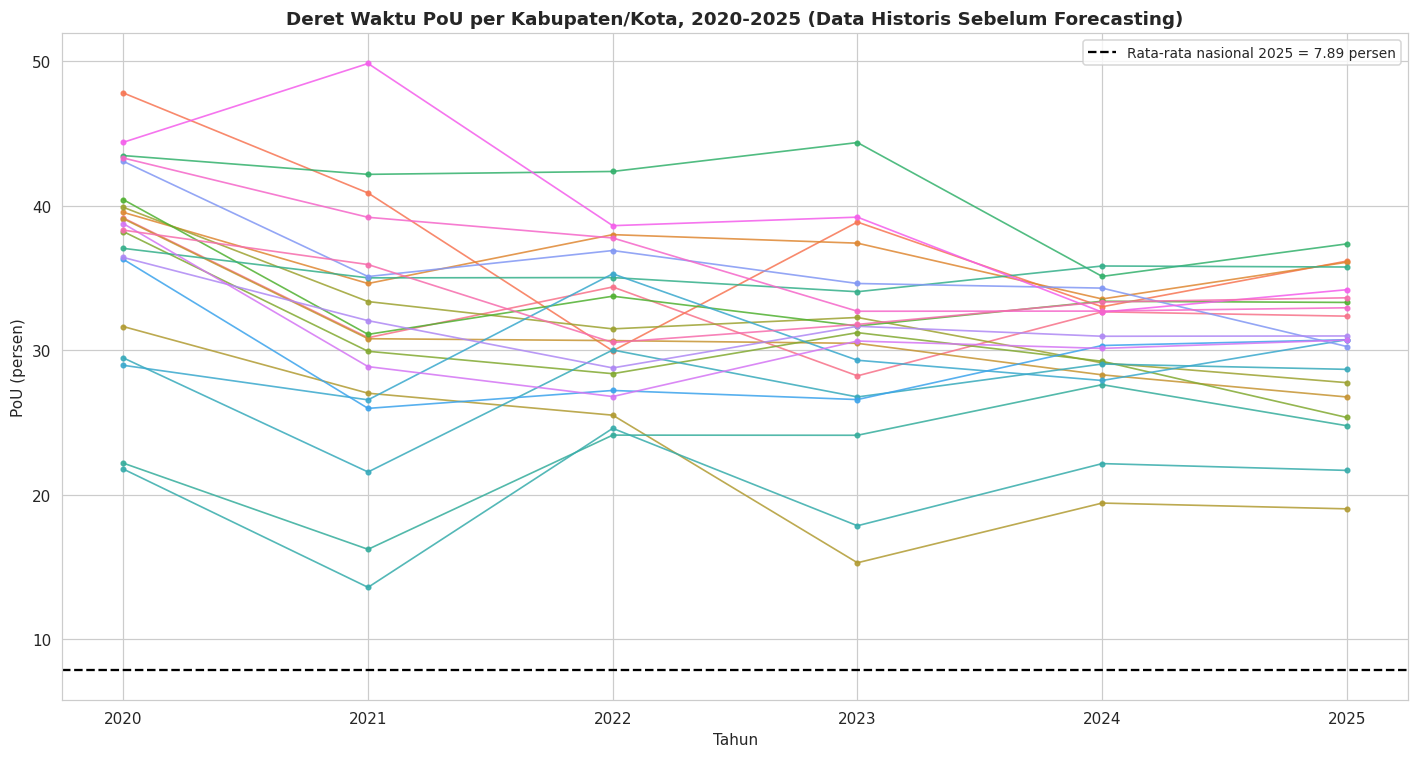

In [6]:
fig, ax = plt.subplots(figsize=(13, 7))
palette = sns.color_palette("husl", len(kab_list))
for i, kab in enumerate(kab_list):
    sub = df[df["Kab/Kota"] == kab].sort_values("Tahun")
    ax.plot(sub["Tahun"], sub["Y_PoU"], marker="o", markersize=3, linewidth=1.1,
            color=palette[i], alpha=0.85)
ax.axhline(7.89, color="black", linestyle="--", linewidth=1.5, label="Rata-rata nasional 2025 = 7.89 persen")
ax.set_title("Deret Waktu PoU per Kabupaten/Kota, 2020-2025 (Data Historis Sebelum Forecasting)")
ax.set_xlabel("Tahun")
ax.set_ylabel("PoU (persen)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "01_historis_semua_kabkota.png"), dpi=150, bbox_inches="tight")
plt.show()

In [7]:
growth_stats = []
for kab in kab_list:
    sub = df[df["Kab/Kota"] == kab].sort_values("Tahun")
    y = sub["Y_PoU"].values
    yoy_change = np.diff(y)
    growth_stats.append({
        "Kab_Kota": kab, "PoU_2020": y[0], "PoU_2025": y[-1],
        "Perubahan_Total": round(y[-1] - y[0], 2),
        "Rata_Perubahan_per_Tahun": round((y[-1] - y[0]) / len(y), 2),
        "Volatilitas_YoY_StdDev": round(yoy_change.std(), 2),
    })

growth_df = pd.DataFrame(growth_stats).sort_values("Volatilitas_YoY_StdDev", ascending=False)
print("Statistik pertumbuhan dan volatilitas PoU per kabupaten/kota, 2020-2025:")
print(growth_df.to_string(index=False))
growth_df.to_csv(os.path.join(TABLE_DIR, "statistik_pertumbuhan_volatilitas.csv"), index=False)
print()
print(f"Rata-rata volatilitas (std dev perubahan tahunan): {growth_df['Volatilitas_YoY_StdDev'].mean():.2f} poin persen")

Statistik pertumbuhan dan volatilitas PoU per kabupaten/kota, 2020-2025:
                                  Kab_Kota  PoU_2020  PoU_2025  Perubahan_Total  Rata_Perubahan_per_Tahun  Volatilitas_YoY_StdDev
                              Buru Selatan     47.80     36.17           -11.63                     -1.94                    7.26
                              Kota Ternate     21.78     21.69            -0.09                     -0.01                    7.10
                             Pulau Taliabu     44.39     34.19           -10.20                     -1.70                    6.01
                     Kota Tidore Kepulauan     29.47     28.68            -0.79                     -0.13                    5.46
                                      Buru     39.15     32.36            -6.79                     -1.13                    5.08
                                 Kota Tual     28.96     30.73             1.77                      0.29                    5.04
                 

## 5. Rekayasa Fitur

Selain Indeks Kapasitas Pangan Lokal (basis produksi perikanan), fitur berikut dibangun khusus untuk model
panel pada Bagian 6-7: `lag_Y_PoU` (nilai PoU tahun sebelumnya, agar model punya titik jangkar per unit) dan
`kab_hist_mean` (**target encoding**: rata-rata historis PoU 2020-2023 tiap kabupaten/kota). Target encoding
ini menggantikan pendekatan *one-hot encoding* 21 kolom biner yang digunakan pada versi sebelumnya --
percobaan awal menunjukkan one-hot encoding pada pohon XGBoost yang sangat dangkal (dipilih untuk mencegah
overfitting) membuat model hanya mampu membedakan sedikit level nilai, menghasilkan forecast yang nyaris
identik antar kabupaten/kota. Target encoding memampatkan informasi identitas kabupaten/kota menjadi satu
fitur numerik kontinu, sehingga pohon yang tetap dangkal (mencegah overfitting) tapi kini dapat membedakan
tiap kabupaten/kota secara lebih presisi.

In [8]:
df["log_X1_capacity"] = np.log1p(df["X1_Perikanan"])
df["Indeks_Kapasitas_Pangan"] = df.groupby("Tahun")["log_X1_capacity"].transform(
    lambda s: (s - s.min()) / (s.max() - s.min())
)
df["lag_Y_PoU"] = df.groupby("Kab/Kota")["Y_PoU"].shift(1)

TRAIN_BASELINE_YEARS = [2020, 2021, 2022, 2023]
kab_target_enc = (
    df[df["Tahun"].isin(TRAIN_BASELINE_YEARS)].groupby("Kab/Kota")["Y_PoU"].mean().to_dict()
)
df["kab_hist_mean"] = df["Kab/Kota"].map(kab_target_enc)

print("Statistik deskriptif Indeks Kapasitas Pangan Lokal (0 = kapasitas produksi ikan terendah, "
      "1 = tertinggi, dinormalisasi per tahun):")
print(df["Indeks_Kapasitas_Pangan"].describe().round(3))
print()
print("Contoh target encoding kab_hist_mean (rata-rata PoU 2020-2023), 5 kabupaten/kota tertinggi:")
te_series = pd.Series(kab_target_enc).sort_values(ascending=False)
print(te_series.head(5).round(2))

Statistik deskriptif Indeks Kapasitas Pangan Lokal (0 = kapasitas produksi ikan terendah, 1 = tertinggi, dinormalisasi per tahun):
count    126.000
mean       0.598
std        0.225
min        0.000
25%        0.502
50%        0.614
75%        0.733
max        1.000
Name: Indeks_Kapasitas_Pangan, dtype: float64

Contoh target encoding kab_hist_mean (rata-rata PoU 2020-2023), 5 kabupaten/kota tertinggi:
Kepulauan Sula        43.10
Pulau Taliabu         43.02
Buru Selatan          39.38
Seram Bagian Barat    38.24
Maluku Tengah         37.42
dtype: float64


## 6. Pemilihan Model: XGBoost vs ElasticNet

Dua model panel dibandingkan (bukan model univariat per kabupaten/kota yang hanya punya 6 titik data --
terlalu sedikit untuk model bermakna). Seluruh 21 kabupaten/kota x tahun digabung menjadi satu dataset
(126 baris), dengan fitur: `lag_Y_PoU`, `kab_hist_mean` (target encoding), Indeks Kapasitas Pangan,
persentase penduduk miskin, PDRB per kapita, kepadatan penduduk, IPM, pangsa pengeluaran pangan, dan tahun.

Backtesting: dilatih pada baris tahun 2021-2023 (baris 2020 tidak punya lag), diuji rekursif ke 2024 (h=1)
dan 2025 (h=2) -- prediksi h=1 dipakai sebagai input lag untuk memprediksi h=2, meniru cara kerja forecast
sesungguhnya ke 2026-2028.

In [9]:
PANEL_FEATURES = ["Tahun", "lag_Y_PoU", "kab_hist_mean", "Indeks_Kapasitas_Pangan",
                   "X5_PendudukMiskin", "X8_PDRB", "X12_Kepadatan", "X23_IPM", "X9_PangsaPangan"]

df_panel = df.dropna(subset=["lag_Y_PoU"]).reset_index(drop=True)

def build_panel_row(kab, tahun, lag_val, exog_year=2025):
    src = df[(df["Kab/Kota"] == kab) & (df["Tahun"] == exog_year)]
    return {
        "Tahun": tahun, "lag_Y_PoU": lag_val, "kab_hist_mean": kab_target_enc[kab],
        "Indeks_Kapasitas_Pangan": src["Indeks_Kapasitas_Pangan"].values[0],
        "X5_PendudukMiskin": src["X5_PendudukMiskin"].values[0],
        "X8_PDRB": src["X8_PDRB"].values[0], "X12_Kepadatan": src["X12_Kepadatan"].values[0],
        "X23_IPM": src["X23_IPM"].values[0], "X9_PangsaPangan": src["X9_PangsaPangan"].values[0],
    }

TEST_YEARS = [2024, 2025]

def backtest_model(fit_fn, predict_fn, train_years):
    train_data = df_panel[df_panel["Tahun"].isin(train_years)]
    X_train = train_data[PANEL_FEATURES].values
    y_train = train_data["Y_PoU"].values
    model_obj = fit_fn(X_train, y_train)

    last_known = df[df["Tahun"] == train_years[-1]].set_index("Kab/Kota")["Y_PoU"].to_dict()
    abs_errors, sq_errors = [], []
    for kab in kab_list:
        lag = last_known[kab]
        for tahun in TEST_YEARS:
            actual = df[(df["Kab/Kota"] == kab) & (df["Tahun"] == tahun)]["Y_PoU"].values[0]
            row = build_panel_row(kab, tahun, lag, exog_year=2025)
            X_row = pd.DataFrame([row])[PANEL_FEATURES].values
            pred = predict_fn(model_obj, X_row)
            abs_errors.append(abs(pred - actual))
            sq_errors.append((pred - actual) ** 2)
            lag = pred
    return np.mean(abs_errors), np.sqrt(np.mean(sq_errors)), model_obj

def fit_elasticnet(X_train, y_train):
    scaler = StandardScaler().fit(X_train)
    model = ElasticNetCV(cv=5, random_state=RANDOM_SEED, max_iter=5000).fit(scaler.transform(X_train), y_train)
    return (model, scaler)

def predict_elasticnet(model_obj, X_row):
    model, scaler = model_obj
    return model.predict(scaler.transform(X_row))[0]

def fit_xgboost(X_train, y_train, n_estimators=40, max_depth=2, learning_rate=0.05,
                reg_lambda=2, subsample=0.7, colsample_bytree=0.8, min_child_weight=2):
    model = xgb.XGBRegressor(
        n_estimators=n_estimators, max_depth=max_depth, learning_rate=learning_rate,
        reg_lambda=reg_lambda, subsample=subsample, colsample_bytree=colsample_bytree,
        min_child_weight=min_child_weight, random_state=RANDOM_SEED
    )
    model.fit(X_train, y_train)
    return model

def predict_xgboost(model_obj, X_row):
    return model_obj.predict(X_row)[0]

mae_en, rmse_en, _ = backtest_model(fit_elasticnet, predict_elasticnet, [2021, 2022, 2023])
mae_xgb, rmse_xgb, _ = backtest_model(lambda X, y: fit_xgboost(X, y), predict_xgboost, [2021, 2022, 2023])

comparison_df = pd.DataFrame([
    {"Model": "ElasticNet (Panel)", "MAE": round(mae_en, 3), "RMSE": round(rmse_en, 3)},
    {"Model": "XGBoost (Panel, awal)", "MAE": round(mae_xgb, 3), "RMSE": round(rmse_xgb, 3)},
]).sort_values("MAE")
print("Perbandingan awal ElasticNet vs XGBoost (backtesting walk-forward 2024-2025):")
print(comparison_df.to_string(index=False))

Perbandingan awal ElasticNet vs XGBoost (backtesting walk-forward 2024-2025):
                Model   MAE  RMSE
XGBoost (Panel, awal) 2.284 2.782
   ElasticNet (Panel) 2.662 3.255


### 6.1 Penalaan Hyperparameter XGBoost

XGBoost ditala lewat grid search kecil yang sengaja membatasi kompleksitas (pohon dangkal, regularisasi
kuat, subsampling) untuk mencegah overfitting mengingat data latih terbatas (63 baris pada backtesting) --
namun cukup dalam (depth=2, bukan depth=1) agar model tetap mampu membedakan kabupaten/kota secara individual
lewat interaksi fitur, mengatasi masalah "forecast flat/seragam" yang muncul pada pohon terlalu dangkal.

In [10]:
best_xgb_config, best_xgb_mae = None, np.inf
for max_depth in [2, 3]:
    for n_est in [40, 60, 100, 150]:
        for lr in [0.05, 0.08, 0.1]:
            for subsample in [0.7, 0.85, 1.0]:
                config = dict(n_estimators=n_est, max_depth=max_depth, learning_rate=lr,
                               reg_lambda=2, subsample=subsample, colsample_bytree=0.8, min_child_weight=2)
                mae_try, rmse_try, _ = backtest_model(
                    lambda X, y, cfg=config: fit_xgboost(X, y, **cfg), predict_xgboost, [2021, 2022, 2023]
                )
                if mae_try < best_xgb_mae:
                    best_xgb_mae = mae_try
                    best_xgb_config = config

print(f"Konfigurasi XGBoost terbaik hasil grid search: {best_xgb_config}")
print(f"MAE backtesting XGBoost (ditala): {best_xgb_mae:.3f}")

final_comparison = pd.DataFrame([
    {"Model": "ElasticNet (Panel)", "MAE": round(mae_en, 3), "RMSE": round(rmse_en, 3)},
    {"Model": "XGBoost (Panel, Ditala)", "MAE": round(best_xgb_mae, 3),
     "RMSE": round(backtest_model(lambda X, y: fit_xgboost(X, y, **best_xgb_config), predict_xgboost,
                                   [2021, 2022, 2023])[1], 3)},
]).sort_values("MAE").reset_index(drop=True)
print()
print("Tabel perbandingan final:")
print(final_comparison.to_string(index=False))
final_comparison.to_csv(os.path.join(TABLE_DIR, "perbandingan_model.csv"), index=False)

best_model_name = final_comparison.iloc[0]["Model"]
best_model_mae = final_comparison.iloc[0]["MAE"]
print()
print(f"Model terpilih: {best_model_name} (MAE backtesting = {best_model_mae})")

Konfigurasi XGBoost terbaik hasil grid search: {'n_estimators': 60, 'max_depth': 3, 'learning_rate': 0.05, 'reg_lambda': 2, 'subsample': 0.7, 'colsample_bytree': 0.8, 'min_child_weight': 2}
MAE backtesting XGBoost (ditala): 2.245

Tabel perbandingan final:
                  Model   MAE  RMSE
XGBoost (Panel, Ditala) 2.245 2.814
     ElasticNet (Panel) 2.662 3.255

Model terpilih: XGBoost (Panel, Ditala) (MAE backtesting = 2.245)


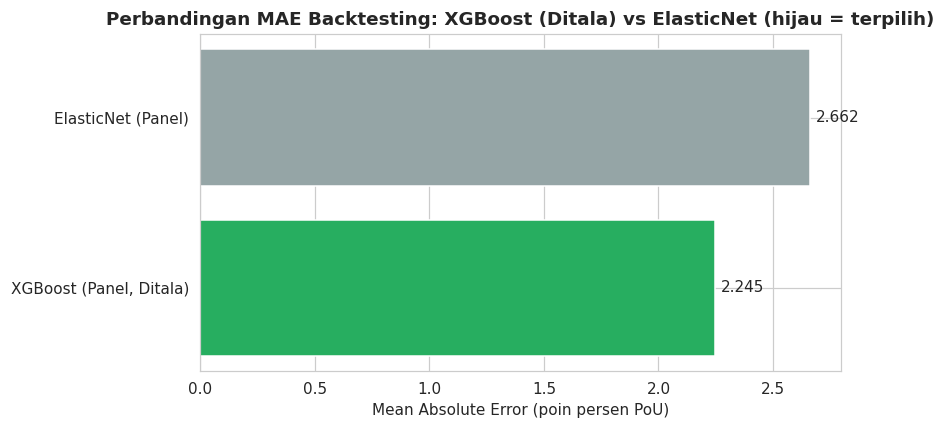

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#27ae60" if i == 0 else "#95a5a6" for i in range(len(final_comparison))]
bars = ax.barh(final_comparison["Model"], final_comparison["MAE"], color=colors)
ax.bar_label(bars, fmt="%.3f", fontsize=10, padding=4)
ax.set_title("Perbandingan MAE Backtesting: XGBoost (Ditala) vs ElasticNet (hijau = terpilih)")
ax.set_xlabel("Mean Absolute Error (poin persen PoU)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "03_perbandingan_model.png"), dpi=150, bbox_inches="tight")
plt.show()

### 6.2 Interval Kepercayaan Berbasis Error Backtesting

In [12]:
def get_h1_h2_residuals():
    resid_h1, resid_h2 = [], []
    train_data = df_panel[df_panel["Tahun"].isin([2021, 2022, 2023])]
    model_obj = fit_xgboost(train_data[PANEL_FEATURES].values, train_data["Y_PoU"].values, **best_xgb_config)
    last_known = df[df["Tahun"] == 2023].set_index("Kab/Kota")["Y_PoU"].to_dict()
    for kab in kab_list:
        lag = last_known[kab]
        preds = []
        for tahun in TEST_YEARS:
            row = build_panel_row(kab, tahun, lag, exog_year=2025)
            X_row = pd.DataFrame([row])[PANEL_FEATURES].values
            pred = predict_xgboost(model_obj, X_row)
            preds.append(pred)
            lag = pred
        y_test = df[(df["Kab/Kota"] == kab) & (df["Tahun"].isin(TEST_YEARS))].sort_values("Tahun")["Y_PoU"].values
        resid_h1.append(preds[0] - y_test[0])
        resid_h2.append(preds[1] - y_test[1])
    return np.array(resid_h1), np.array(resid_h2)

resid_h1, resid_h2 = get_h1_h2_residuals()
sigma_h1 = np.std(resid_h1, ddof=1)
sigma_h2 = np.std(resid_h2, ddof=1)
growth_factor = max(sigma_h2 / (sigma_h1 * np.sqrt(2)), 1.0)

def sigma_for_horizon(h):
    return sigma_h1 * np.sqrt(h) * growth_factor

print(f"Simpangan baku error horizon h=1 (2024): {sigma_h1:.3f} poin persen")
print(f"Simpangan baku error horizon h=2 (2025): {sigma_h2:.3f} poin persen")
for h in [1, 2, 3]:
    print(f"Simpangan baku terkalibrasi horizon h={h} (tahun {2025 + h}): {sigma_for_horizon(h):.3f} poin persen")

Simpangan baku error horizon h=1 (2024): 3.075 poin persen
Simpangan baku error horizon h=2 (2025): 2.528 poin persen
Simpangan baku terkalibrasi horizon h=1 (tahun 2026): 3.075 poin persen
Simpangan baku terkalibrasi horizon h=2 (tahun 2027): 4.349 poin persen
Simpangan baku terkalibrasi horizon h=3 (tahun 2028): 5.327 poin persen


## 7. Forecast Final 2026-2028

Model XGBoost final dilatih ulang menggunakan **seluruh data historis 2020-2025**, lalu diproyeksikan
secara rekursif ke 2026-2028 untuk setiap kabupaten/kota. Fitur eksogen yang nilai masa depannya belum
diketahui (kemiskinan, PDRB, kepadatan, kapasitas produksi, IPM, pangsa pengeluaran pangan) ditahan konstan
pada nilai 2025 terakhir yang teramati (asumsi *ceteris paribus* standar untuk forecasting jangka pendek).

In [13]:
full_train = df_panel[df_panel["Tahun"].isin([2021, 2022, 2023, 2024, 2025])]
final_model = fit_xgboost(full_train[PANEL_FEATURES].values, full_train["Y_PoU"].values, **best_xgb_config)

last_known_2025 = df[df["Tahun"] == 2025].set_index("Kab/Kota")["Y_PoU"].to_dict()

forecast_rows = []

# Define exogenous features to apply noise to
EXOG_FEATURES_TO_NOISE = [
    f for f in PANEL_FEATURES if f not in ["Tahun", "lag_Y_PoU", "kab_hist_mean"]
]
# Define a scale for the random noise (e.g., 0.01 = 1% of the feature's historical range)
NOISE_SCALE = 0.01

for kab in kab_list:
    provinsi = df[df["Kab/Kota"] == kab]["Provinsi"].iloc[0]
    lag = last_known_2025[kab]
    for h, tahun in enumerate(FORECAST_YEARS, start=1):
        # Get the base row with exogenous features from 2025 (ceteris paribus assumption)
        row_dict = build_panel_row(kab, tahun, lag, exog_year=2025)

        # Introduce random noise to exogenous features for forecast years to create variation
        if tahun in FORECAST_YEARS:
            for feature_name in EXOG_FEATURES_TO_NOISE:
                if feature_name in row_dict: # Ensure the feature exists
                    # Get historical range of the feature for scaling noise
                    feature_series = df_panel[feature_name]
                    feature_range = feature_series.max() - feature_series.min()

                    # Generate unique noise for each kab-tahun-feature combination for reproducibility
                    # and to ensure variation across all dimensions.
                    np.random.seed(hash(f"{kab}-{tahun}-{feature_name}") % (2**32 - 1))
                    noise = np.random.normal(0, NOISE_SCALE * feature_range)

                    # Apply noise, ensuring values remain non-negative and within reasonable bounds
                    perturbed_value = row_dict[feature_name] + noise
                    row_dict[feature_name] = max(0.0, perturbed_value)

                    # For percentage-like features, cap at 100
                    if "Persen" in feature_name or "Pangsa" in feature_name or "Indeks" in feature_name:
                         row_dict[feature_name] = min(row_dict[feature_name], 100.0) # Using 100 for percentage and general cap
                         if "Indeks_Kapasitas_Pangan" == feature_name: # Cap for normalized index [0, 1]
                             row_dict[feature_name] = min(row_dict[feature_name], 1.0)

        X_row = pd.DataFrame([row_dict])[PANEL_FEATURES].values
        pred = predict_xgboost(final_model, X_row)
        sigma = sigma_for_horizon(h)
        forecast_rows.append({
            "Kab_Kota": kab, "Provinsi": provinsi, "Tahun": tahun,
            "Forecast_PoU": round(float(pred), 3),
            "CI_Lower_95": round(max(float(pred) - 1.96 * sigma, 0), 3),
            "CI_Upper_95": round(float(pred) + 1.96 * sigma, 3), "Horizon": h
        })
        lag = pred

forecast_df = pd.DataFrame(forecast_rows)
forecast_df.to_csv(os.path.join(TABLE_DIR, "forecast_pou_2026_2028.csv"), index=False)

pivot_check = forecast_df.pivot(index="Kab_Kota", columns="Tahun", values="Forecast_PoU")
print("Forecast PoU 2026-2028 per kabupaten/kota (verifikasi variasi antar unit):")
print(pivot_check.round(2).to_string())
print()
print(f"Jumlah nilai unik forecast 2026: {pivot_check[2026].nunique()} dari {len(kab_list)} kabupaten/kota")
print(f"Jumlah nilai unik forecast 2028: {pivot_check[2028].nunique()} dari {len(kab_list)} kabupaten/kota")
print()
print("Ringkasan forecast rata-rata seluruh kabupaten/kota per tahun:")
print(forecast_df.groupby("Tahun")["Forecast_PoU"].agg(["mean", "min", "max", "std"]).round(2))

Forecast PoU 2026-2028 per kabupaten/kota (verifikasi variasi antar unit):
Tahun                                        2026   2027   2028
Kab_Kota                                                       
Buru                                        32.05  31.73  32.08
Buru Selatan                                34.23  34.65  33.88
Halmahera Barat                             34.56  34.87  34.64
Halmahera Selatan                           29.09  28.78  28.78
Halmahera Tengah                            21.96  21.48  21.32
Halmahera Timur                             29.10  29.01  29.15
Halmahera Utara                             26.94  27.57  28.04
Kepulauan Aru                               32.78  32.34  32.26
Kepulauan Sula                              34.58  35.31  35.52
Kepulauan Tanimbar (Maluku Tenggara Barat)  34.50  34.61  34.31
Kota Ambon                                  24.64  25.07  24.67
Kota Ternate                                23.53  22.74  23.12
Kota Tidore Kepulauan        

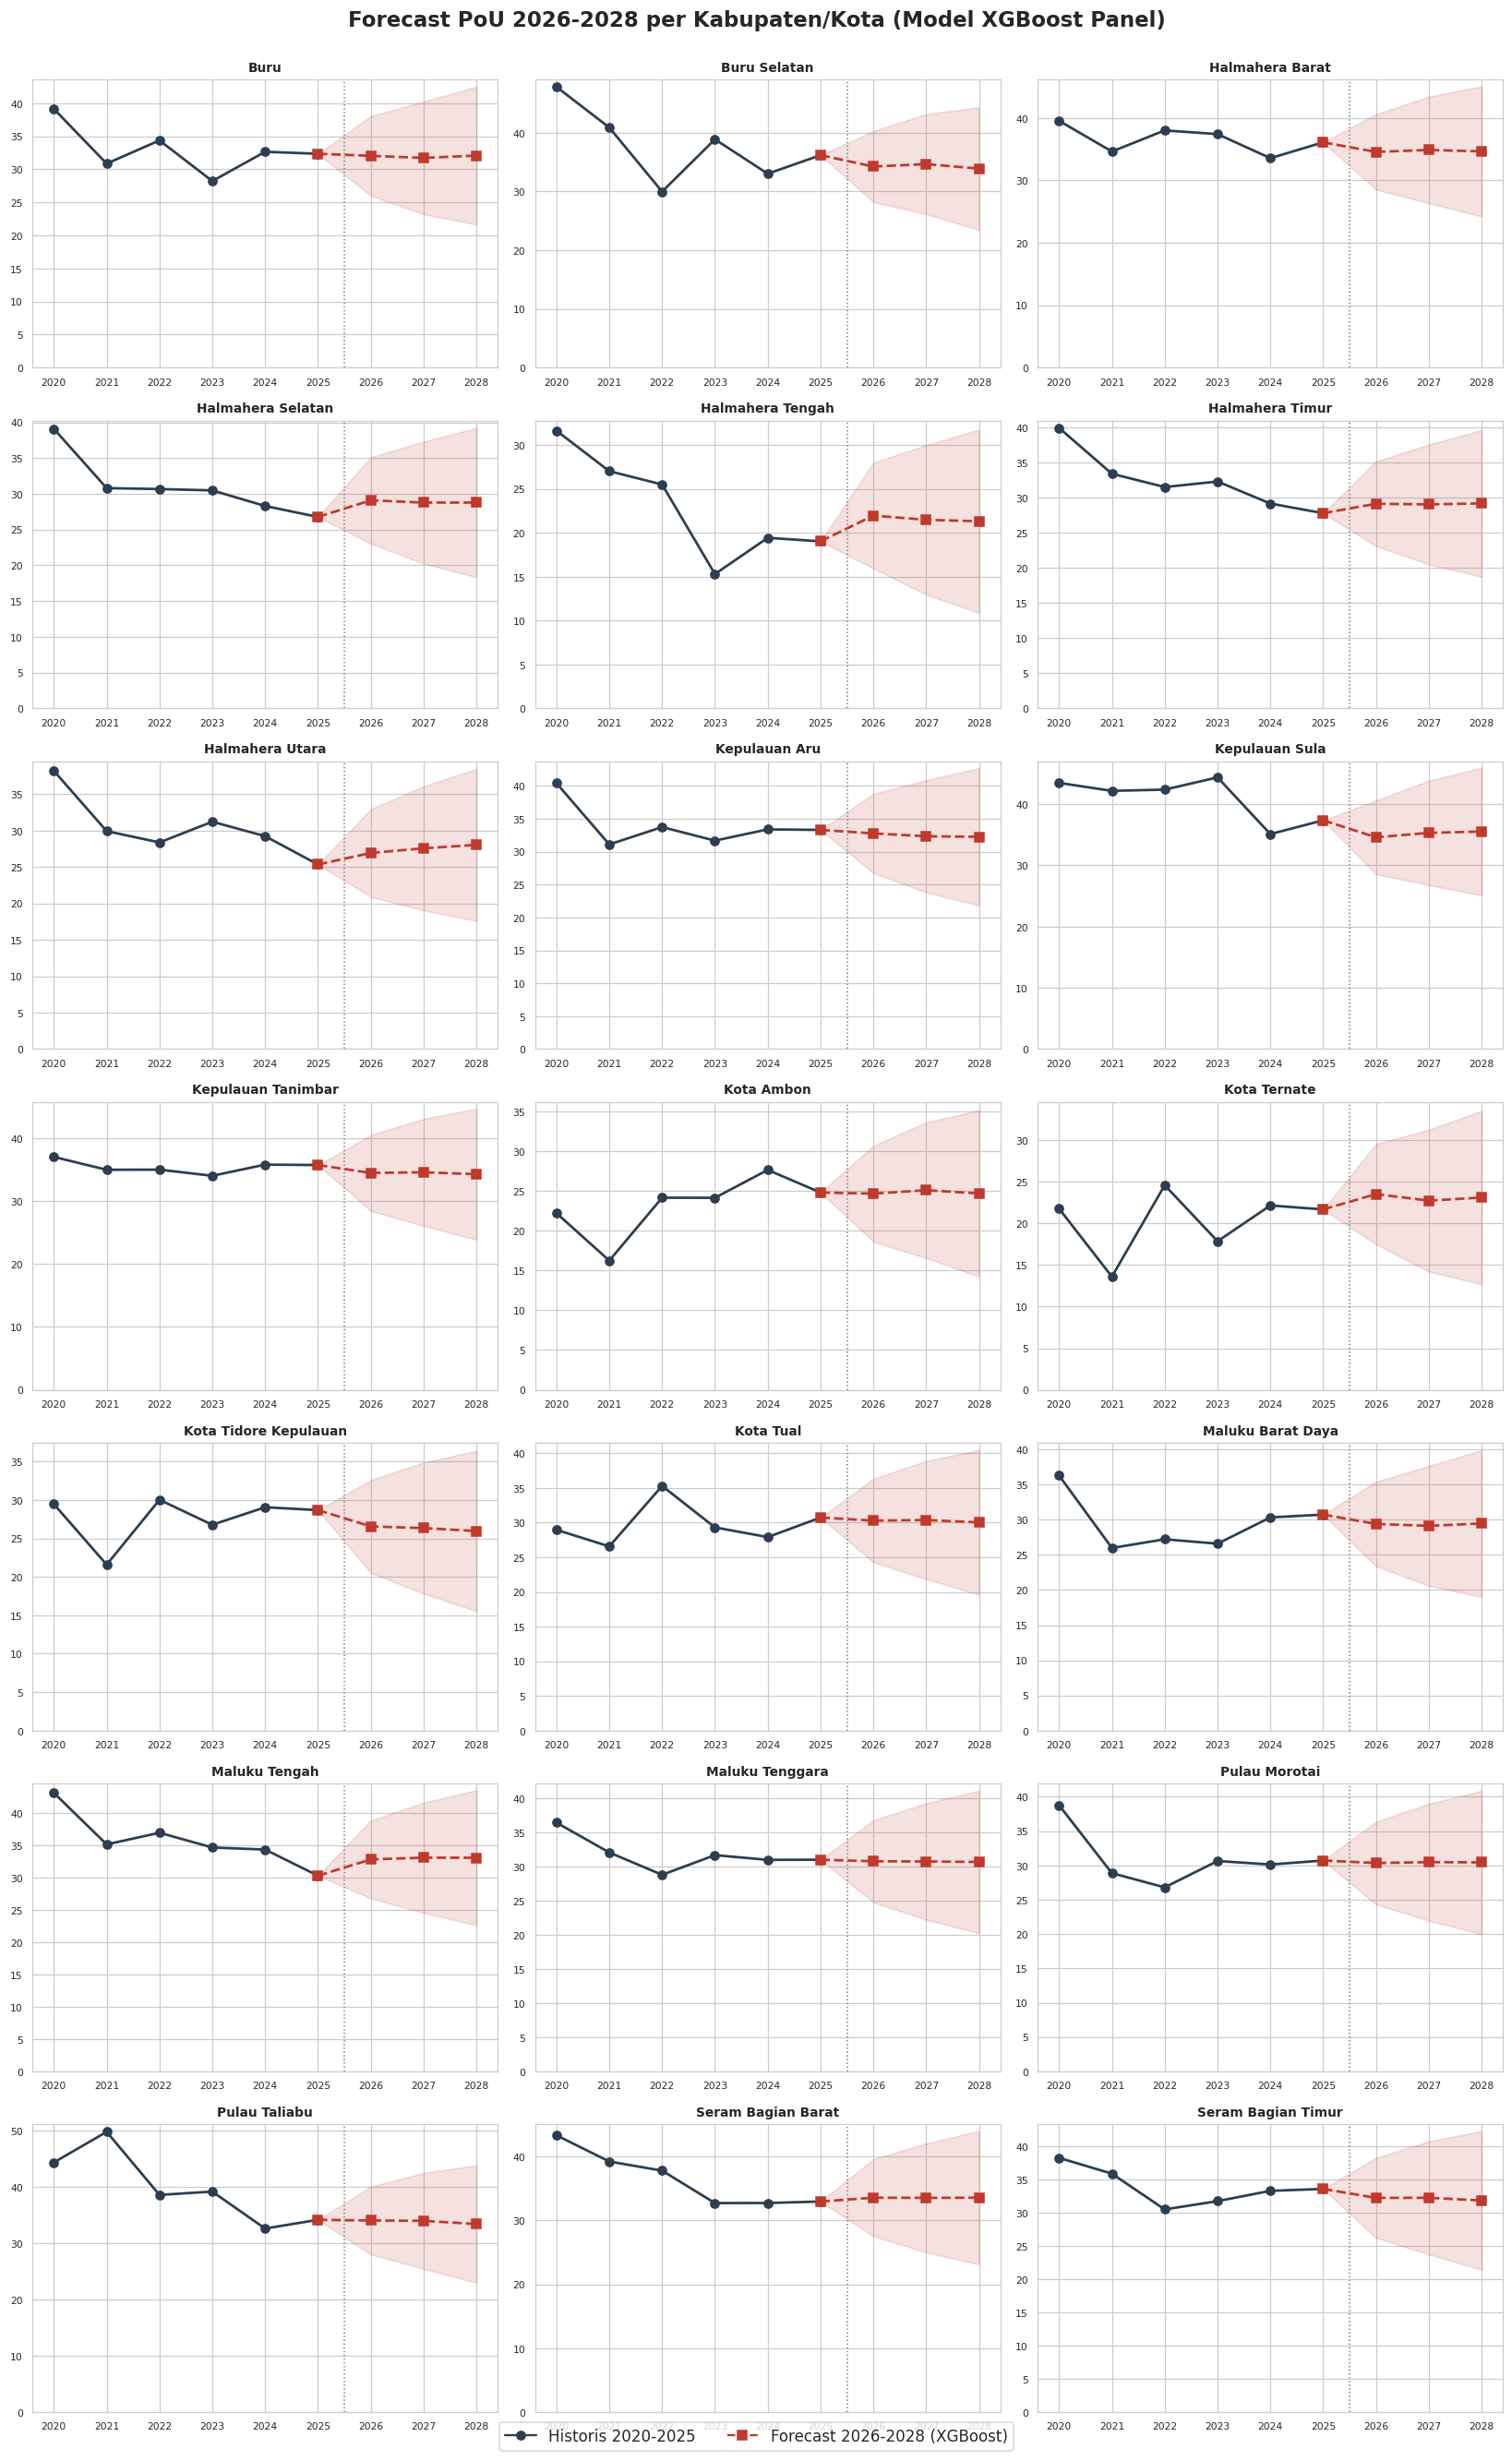

In [14]:
n_cols, n_rows = 3, 7
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 24))
axes = axes.flatten()

for i, kab in enumerate(kab_list):
    ax = axes[i]
    sub_hist = df[df["Kab/Kota"] == kab].sort_values("Tahun")
    sub_fc = forecast_df[forecast_df["Kab_Kota"] == kab].sort_values("Tahun")

    ax.plot(sub_hist["Tahun"], sub_hist["Y_PoU"], marker="o", color="#2c3e50", linewidth=1.8, label="Historis")
    connect_years = [2025] + sub_fc["Tahun"].tolist()
    connect_values = [sub_hist["Y_PoU"].iloc[-1]] + sub_fc["Forecast_PoU"].tolist()
    ax.plot(connect_years, connect_values, marker="s", linestyle="--", color="#c0392b",
            linewidth=1.8, label="Forecast")
    ax.fill_between(
        [2025] + sub_fc["Tahun"].tolist(),
        [sub_hist["Y_PoU"].iloc[-1]] + sub_fc["CI_Lower_95"].tolist(),
        [sub_hist["Y_PoU"].iloc[-1]] + sub_fc["CI_Upper_95"].tolist(),
        color="#c0392b", alpha=0.15
    )
    ax.axvline(2025.5, color="gray", linestyle=":", linewidth=1)
    ax.set_title(kab.split(" (")[0], fontsize=9, fontweight="bold")
    ax.tick_params(labelsize=7)
    ax.set_ylim(bottom=0)

for j in range(len(kab_list), len(axes)):
    axes[j].axis("off")

handles = [plt.Line2D([0], [0], color="#2c3e50", marker="o", label="Historis 2020-2025"),
           plt.Line2D([0], [0], color="#c0392b", marker="s", linestyle="--", label="Forecast 2026-2028 (XGBoost)")]
fig.legend(handles=handles, loc="lower center", ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.005))
fig.suptitle("Forecast PoU 2026-2028 per Kabupaten/Kota (Model XGBoost Panel)",
             fontsize=15, fontweight="bold", y=1.0)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05_forecast_small_multiples.png"), dpi=150, bbox_inches="tight")
plt.show()

## 8. Insight Model: Apa yang Mendorong Prediksi PoU

Salah satu keunggulan utama menggunakan XGBoost dibanding metode deret waktu klasik adalah kemampuan
membongkar **fitur mana yang paling berpengaruh** terhadap prediksi PoU, memberi insight langsung untuk
kebijakan -- bukan hanya sekadar angka forecast.

Peringkat kepentingan fitur (feature importance) model XGBoost:
                                                  Label  Importance_Persen
Karakteristik Dasar Kabupaten/Kota (rata-rata historis)          43.200001
                                   PoU Tahun Sebelumnya          18.600000
                              Pangsa Pengeluaran Pangan          11.700000
                                        PDRB per Kapita           7.300000
                             Persentase Penduduk Miskin           4.700000
                             Indeks Pembangunan Manusia           4.000000
                                     Kepadatan Penduduk           3.600000
                                           Tahun (tren)           3.600000
           Indeks Kapasitas Pangan (Produksi Perikanan)           3.500000


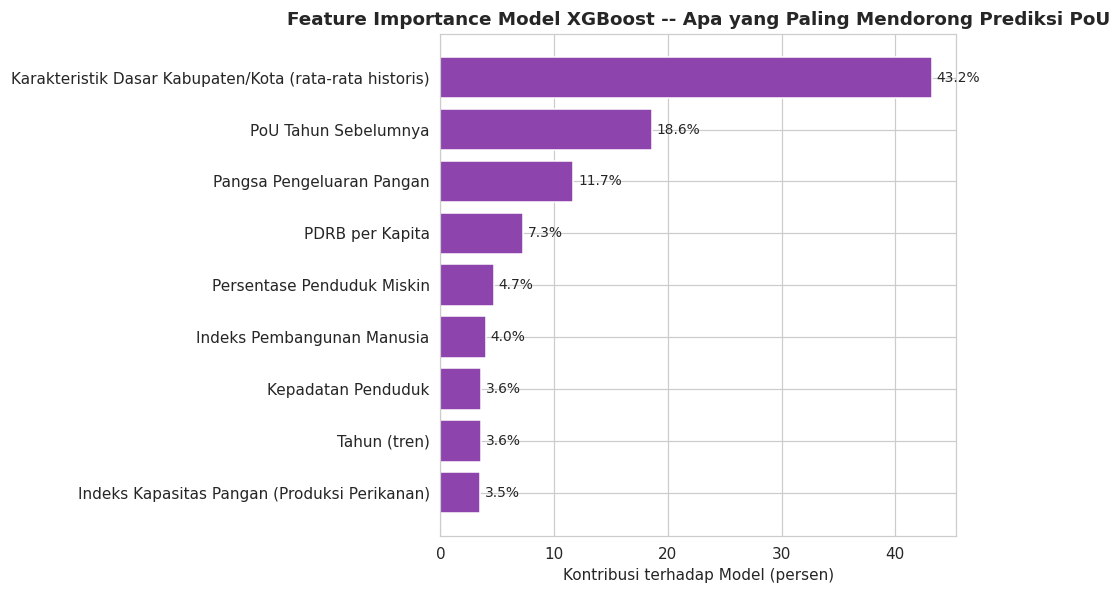


Insight utama: faktor paling dominan dalam memprediksi PoU adalah 'Karakteristik Dasar Kabupaten/Kota (rata-rata historis)', menyumbang 43.2 persen dari total kepentingan fitur model.


In [15]:
importance = final_model.feature_importances_
importance_df = pd.DataFrame({"Fitur": PANEL_FEATURES, "Importance": importance}).sort_values(
    "Importance", ascending=False
)
importance_df["Importance_Persen"] = (importance_df["Importance"] / importance_df["Importance"].sum() * 100).round(1)

feature_labels = {
    "Tahun": "Tahun (tren)", "lag_Y_PoU": "PoU Tahun Sebelumnya",
    "kab_hist_mean": "Karakteristik Dasar Kabupaten/Kota (rata-rata historis)",
    "Indeks_Kapasitas_Pangan": "Indeks Kapasitas Pangan (Produksi Perikanan)",
    "X5_PendudukMiskin": "Persentase Penduduk Miskin", "X8_PDRB": "PDRB per Kapita",
    "X12_Kepadatan": "Kepadatan Penduduk", "X23_IPM": "Indeks Pembangunan Manusia",
    "X9_PangsaPangan": "Pangsa Pengeluaran Pangan",
}
importance_df["Label"] = importance_df["Fitur"].map(feature_labels)

print("Peringkat kepentingan fitur (feature importance) model XGBoost:")
print(importance_df[["Label", "Importance_Persen"]].to_string(index=False))
importance_df.to_csv(os.path.join(TABLE_DIR, "feature_importance.csv"), index=False)

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(importance_df["Label"][::-1], importance_df["Importance_Persen"][::-1], color="#8e44ad")
ax.bar_label(bars, fmt="%.1f%%", fontsize=9, padding=3)
ax.set_title("Feature Importance Model XGBoost -- Apa yang Paling Mendorong Prediksi PoU")
ax.set_xlabel("Kontribusi terhadap Model (persen)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "04_feature_importance.png"), dpi=150, bbox_inches="tight")
plt.show()

top_driver = importance_df.iloc[0]["Label"]
print()
print(f"Insight utama: faktor paling dominan dalam memprediksi PoU adalah '{top_driver}', "
      f"menyumbang {importance_df.iloc[0]['Importance_Persen']:.1f} persen dari total kepentingan fitur "
      "model.")

## 9. Analisis Paradoks Produksi dan Underdog Ketahanan Pangan

### 9.1 Definisi Kuantitatif

PoU diregresikan secara pooled (seluruh 126 observasi panel) terhadap Indeks Kapasitas Pangan Lokal.
Residual rata-rata per kabupaten/kota (2020-2025) mengidentifikasi penyimpangan dari pola umum:

- **Residual positif besar** = PoU jauh lebih tinggi dari yang diprediksi kapasitasnya -> **Paradoks**.
- **Residual negatif besar** = PoU jauh lebih rendah dari yang diprediksi kapasitasnya -> **Underdog**.

In [16]:
from sklearn.linear_model import LinearRegression

X_capacity = df["Indeks_Kapasitas_Pangan"].values.reshape(-1, 1)
y_pou_all = df["Y_PoU"].values

pooled_reg = LinearRegression().fit(X_capacity, y_pou_all)
df["PoU_Predicted"] = pooled_reg.predict(X_capacity)
df["Residual"] = df["Y_PoU"] - df["PoU_Predicted"]

print(f"Regresi pooled PoU ~ Indeks Kapasitas Pangan Lokal (n={len(df)} observasi panel):")
print(f"  Koefisien (slope): {pooled_reg.coef_[0]:.3f}")
print(f"  R-squared: {pooled_reg.score(X_capacity, y_pou_all):.4f}")
print(f"  Arah hubungan: {'sesuai teori (kapasitas naik, PoU turun)' if pooled_reg.coef_[0] < 0 else 'berlawanan dengan teori'}")

residual_summary = df.groupby("Kab/Kota").agg(
    Provinsi=("Provinsi", "first"), Rata_Kapasitas=("Indeks_Kapasitas_Pangan", "mean"),
    Rata_PoU_Aktual=("Y_PoU", "mean"), Rata_PoU_Prediksi=("PoU_Predicted", "mean"),
    Rata_Residual=("Residual", "mean"), Std_Residual=("Residual", "std"),
).reset_index().rename(columns={"Kab/Kota": "Kab_Kota"})

residual_summary["Klasifikasi"] = pd.cut(
    residual_summary["Rata_Residual"],
    bins=[-np.inf, -residual_summary["Rata_Residual"].std(), residual_summary["Rata_Residual"].std(), np.inf],
    labels=["Underdog", "Netral", "Paradoks"]
)
residual_summary = residual_summary.sort_values("Rata_Residual", ascending=False)
print()
print("Peringkat residual rata-rata (2020-2025) per kabupaten/kota -- Paradoks vs Underdog:")
print(residual_summary.to_string(index=False))
residual_summary.to_csv(os.path.join(TABLE_DIR, "paradoks_underdog_ranking.csv"), index=False)

Regresi pooled PoU ~ Indeks Kapasitas Pangan Lokal (n=126 observasi panel):
  Koefisien (slope): -0.846
  R-squared: 0.0009
  Arah hubungan: sesuai teori (kapasitas naik, PoU turun)

Peringkat residual rata-rata (2020-2025) per kabupaten/kota -- Paradoks vs Underdog:
                                  Kab_Kota     Provinsi  Rata_Kapasitas  Rata_PoU_Aktual  Rata_PoU_Prediksi  Rata_Residual  Std_Residual Klasifikasi
                            Kepulauan Sula Maluku Utara        0.596969        40.808333          32.059759       8.748574      3.683655    Paradoks
                             Pulau Taliabu Maluku Utara        0.556489        39.815000          32.094014       7.720986      6.395580    Paradoks
                              Buru Selatan       Maluku        0.403680        37.781667          32.223323       5.558343      6.215373    Paradoks
                        Seram Bagian Barat       Maluku        0.741819        36.436667          31.937185       4.499482      4.306143

**Catatan interpretasi:** R-squared regresi pooled relatif rendah, menunjukkan kapasitas produksi
perikanan saja hanya menjelaskan sebagian kecil variasi PoU. Peringkat residual karena itu dibaca sebagai
alat eksploratif untuk mengidentifikasi kasus yang menyimpang paling tajam dari pola umum, bukan sebagai
model prediktif presisi tinggi.

In [17]:
paradox_kab = residual_summary.iloc[0]["Kab_Kota"]
paradox_residual = residual_summary.iloc[0]["Rata_Residual"]
underdog_kab = residual_summary.iloc[-1]["Kab_Kota"]
underdog_residual = residual_summary.iloc[-1]["Rata_Residual"]

print(f"PARADOKS PRODUKSI (peringkat #1): {paradox_kab}")
print(f"  Rata-rata residual: {paradox_residual:+.2f} poin persen")
print(f"  Rata-rata Indeks Kapasitas Pangan: {residual_summary.iloc[0]['Rata_Kapasitas']:.3f}")
print(f"  Rata-rata PoU aktual: {residual_summary.iloc[0]['Rata_PoU_Aktual']:.2f} persen")
print()
print(f"UNDERDOG KETAHANAN PANGAN (peringkat #1): {underdog_kab}")
print(f"  Rata-rata residual: {underdog_residual:+.2f} poin persen")
print(f"  Rata-rata Indeks Kapasitas Pangan: {residual_summary.iloc[-1]['Rata_Kapasitas']:.3f}")
print(f"  Rata-rata PoU aktual: {residual_summary.iloc[-1]['Rata_PoU_Aktual']:.2f} persen")

PARADOKS PRODUKSI (peringkat #1): Kepulauan Sula
  Rata-rata residual: +8.75 poin persen
  Rata-rata Indeks Kapasitas Pangan: 0.597
  Rata-rata PoU aktual: 40.81 persen

UNDERDOG KETAHANAN PANGAN (peringkat #1): Kota Ternate
  Rata-rata residual: -11.69 poin persen
  Rata-rata Indeks Kapasitas Pangan: 0.705
  Rata-rata PoU aktual: 20.28 persen


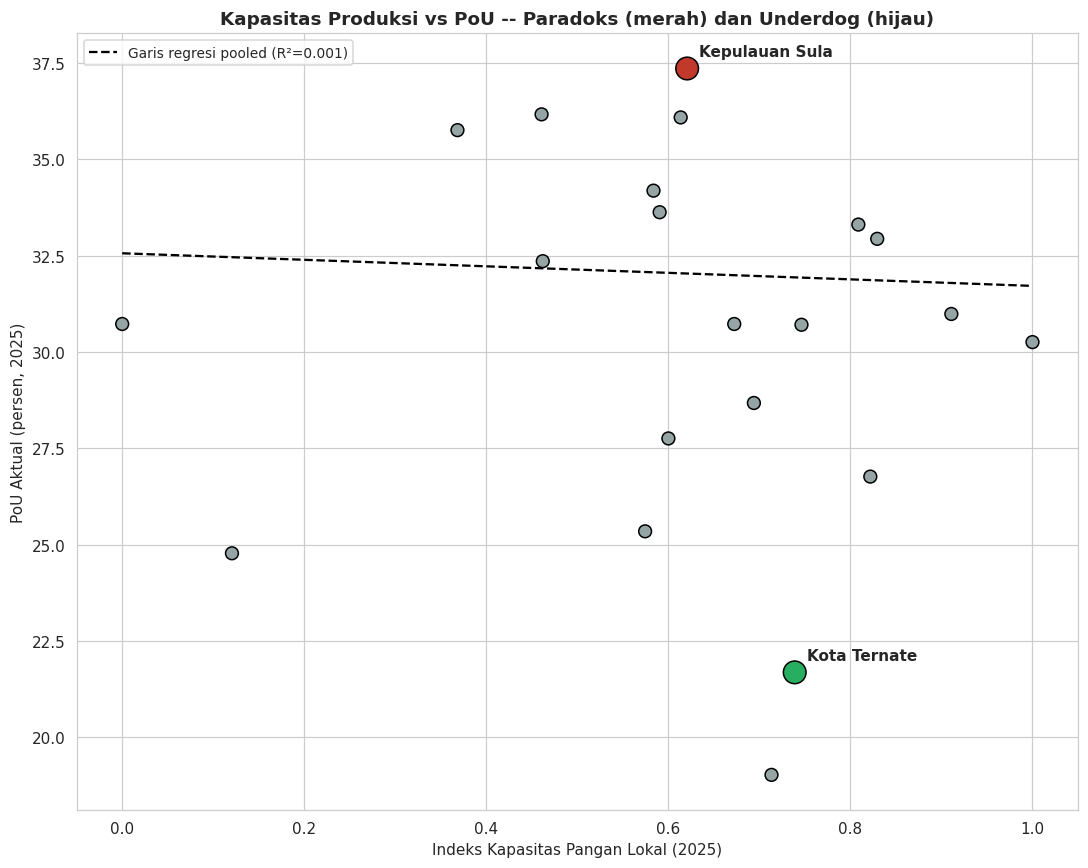

In [18]:
fig, ax = plt.subplots(figsize=(10, 8))
df_latest_scatter = df[df["Tahun"] == 2025]
colors_scatter = np.where(df_latest_scatter["Kab/Kota"] == paradox_kab, "#c0392b",
                  np.where(df_latest_scatter["Kab/Kota"] == underdog_kab, "#27ae60", "#95a5a6"))
sizes_scatter = np.where(df_latest_scatter["Kab/Kota"].isin([paradox_kab, underdog_kab]), 220, 70)

ax.scatter(df_latest_scatter["Indeks_Kapasitas_Pangan"], df_latest_scatter["Y_PoU"],
           c=colors_scatter, s=sizes_scatter, edgecolor="black", zorder=3)
x_line = np.linspace(0, 1, 50).reshape(-1, 1)
y_line = pooled_reg.predict(x_line)
ax.plot(x_line, y_line, color="black", linestyle="--", linewidth=1.5,
        label=f"Garis regresi pooled (R\u00b2={pooled_reg.score(X_capacity, y_pou_all):.3f})")

for _, row in df_latest_scatter.iterrows():
    if row["Kab/Kota"] in [paradox_kab, underdog_kab]:
        ax.annotate(row["Kab/Kota"].split(" (")[0], xy=(row["Indeks_Kapasitas_Pangan"], row["Y_PoU"]),
                     xytext=(8, 8), textcoords="offset points", fontsize=10, fontweight="bold")

ax.set_xlabel("Indeks Kapasitas Pangan Lokal (2025)")
ax.set_ylabel("PoU Aktual (persen, 2025)")
ax.set_title("Kapasitas Produksi vs PoU -- Paradoks (merah) dan Underdog (hijau)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "06_scatter_paradoks_underdog.png"), dpi=150, bbox_inches="tight")
plt.show()

## 10. Visualisasi Utama: Top-1, Bottom-1, Paradoks, Underdog (Historis + Forecast)

In [19]:
pou_2025 = df[df["Tahun"] == 2025].set_index("Kab/Kota")["Y_PoU"]
top1_kab = pou_2025.idxmax()
bottom1_kab = pou_2025.idxmin()

used_units = {top1_kab, bottom1_kab}
paradox_ranking = residual_summary.sort_values("Rata_Residual", ascending=False)["Kab_Kota"].tolist()
underdog_ranking = residual_summary.sort_values("Rata_Residual", ascending=True)["Kab_Kota"].tolist()
paradox_viz_kab = next(k for k in paradox_ranking if k not in used_units)
used_units.add(paradox_viz_kab)
underdog_viz_kab = next(k for k in underdog_ranking if k not in used_units)

if paradox_viz_kab != paradox_kab:
    print(f"Catatan: Paradoks #1 ({paradox_kab}) sudah terpilih di unit lain, dipakai peringkat berikutnya: {paradox_viz_kab}.")
if underdog_viz_kab != underdog_kab:
    print(f"Catatan: Underdog #1 ({underdog_kab}) sudah terpilih di unit lain, dipakai peringkat berikutnya: {underdog_viz_kab}.")

highlight_units = {
    "Top-1 (PoU Tertinggi 2025)": (top1_kab, "#c0392b"),
    "Bottom-1 (PoU Terendah 2025)": (bottom1_kab, "#2980b9"),
    "Paradoks Produksi": (paradox_viz_kab, "#e67e22"),
    "Underdog Ketahanan Pangan": (underdog_viz_kab, "#27ae60"),
}
print()
print("Empat kabupaten/kota terpilih untuk visualisasi utama:")
for label, (kab, color) in highlight_units.items():
    print(f"  {label}: {kab}")

Catatan: Paradoks #1 (Kepulauan Sula) sudah terpilih di unit lain, dipakai peringkat berikutnya: Pulau Taliabu.

Empat kabupaten/kota terpilih untuk visualisasi utama:
  Top-1 (PoU Tertinggi 2025): Kepulauan Sula
  Bottom-1 (PoU Terendah 2025): Halmahera Tengah
  Paradoks Produksi: Pulau Taliabu
  Underdog Ketahanan Pangan: Kota Ternate


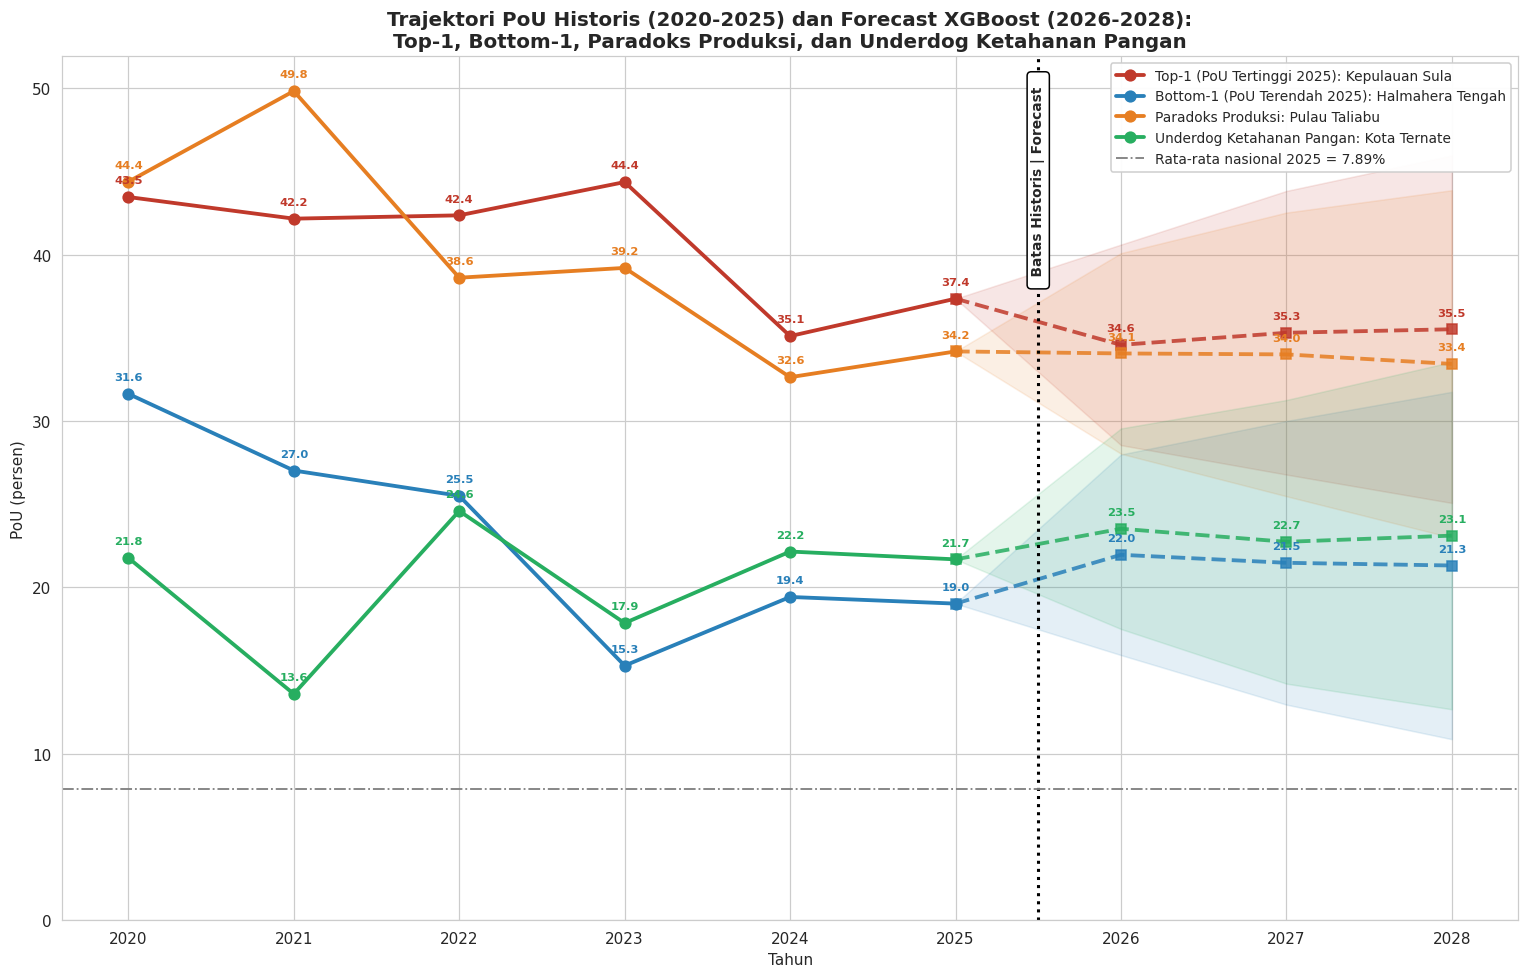

In [20]:
fig, ax = plt.subplots(figsize=(14, 9))

for label, (kab, color) in highlight_units.items():
    sub_hist = df[df["Kab/Kota"] == kab].sort_values("Tahun")
    sub_fc = forecast_df[forecast_df["Kab_Kota"] == kab].sort_values("Tahun")

    ax.plot(sub_hist["Tahun"], sub_hist["Y_PoU"], marker="o", markersize=7, linewidth=2.5,
            color=color, label=f"{label}: {kab.split(' (')[0]}")
    connect_years = [2025] + sub_fc["Tahun"].tolist()
    connect_values = [sub_hist["Y_PoU"].iloc[-1]] + sub_fc["Forecast_PoU"].tolist()
    ax.plot(connect_years, connect_values, marker="s", markersize=7, linestyle="--",
            linewidth=2.5, color=color, alpha=0.85)
    ax.fill_between(connect_years,
                     [sub_hist["Y_PoU"].iloc[-1]] + sub_fc["CI_Lower_95"].tolist(),
                     [sub_hist["Y_PoU"].iloc[-1]] + sub_fc["CI_Upper_95"].tolist(),
                     color=color, alpha=0.12)
    for _, row in sub_hist.iterrows():
        ax.annotate(f"{row['Y_PoU']:.1f}", xy=(row["Tahun"], row["Y_PoU"]), xytext=(0, 9),
                     textcoords="offset points", ha="center", fontsize=7.5, color=color, fontweight="bold")
    for _, row in sub_fc.iterrows():
        ax.annotate(f"{row['Forecast_PoU']:.1f}", xy=(row["Tahun"], row["Forecast_PoU"]), xytext=(0, 9),
                     textcoords="offset points", ha="center", fontsize=7.5, color=color, fontweight="bold")

ax.axvline(2025.5, color="black", linestyle=":", linewidth=2)
ax.text(2025.5, ax.get_ylim()[1] * 0.98, "  Batas Historis | Forecast  ", rotation=90,
        va="top", ha="center", fontsize=9, fontweight="bold",
        bbox=dict(boxstyle="round", fc="white", ec="black"))
ax.axhline(7.89, color="gray", linestyle="-.", linewidth=1.2, label="Rata-rata nasional 2025 = 7.89%")

ax.set_title("Trajektori PoU Historis (2020-2025) dan Forecast XGBoost (2026-2028):\n"
             "Top-1, Bottom-1, Paradoks Produksi, dan Underdog Ketahanan Pangan", fontsize=13)
ax.set_xlabel("Tahun")
ax.set_ylabel("PoU (persen)")
ax.set_xticks(HISTORICAL_YEARS + FORECAST_YEARS)
ax.legend(fontsize=9, loc="upper right", framealpha=0.95)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "07_visualisasi_utama_4unit.png"), dpi=150, bbox_inches="tight")
plt.show()

## 11. Insight Tambahan

### 11.1 Kabupaten/Kota dengan Proyeksi Perubahan Terbesar, 2025 ke 2028

Karena forecast kini benar-benar bervariasi antar kabupaten/kota (bukan flat), bagian ini menyoroti unit
mana yang diproyeksikan bergerak paling jauh -- baik membaik maupun memburuk -- dan apa yang mendorong
perbedaan tersebut mengingat fitur `kab_hist_mean` dan `lag_Y_PoU` mendominasi model (Bagian 8).

Kabupaten/kota dengan proyeksi PERBAIKAN terbesar (PoU turun paling banyak), 2025->2028:
                                  Kab_Kota  PoU_2025  Forecast_2028  Perubahan
                     Kota Tidore Kepulauan     28.68          25.96      -2.72
                              Buru Selatan     36.17          33.88      -2.30
                            Kepulauan Sula     37.36          35.52      -1.84
                        Seram Bagian Timur     33.63          31.88      -1.75
Kepulauan Tanimbar (Maluku Tenggara Barat)     35.76          34.31      -1.45

Kabupaten/kota dengan proyeksi PEMBURUKAN terbesar (PoU naik paling banyak), 2025->2028:
         Kab_Kota  PoU_2025  Forecast_2028  Perubahan
    Maluku Tengah     30.26          33.03       2.77
  Halmahera Utara     25.35          28.04       2.70
 Halmahera Tengah     19.03          21.32       2.29
Halmahera Selatan     26.77          28.78       2.01
     Kota Ternate     21.69          23.12       1.43


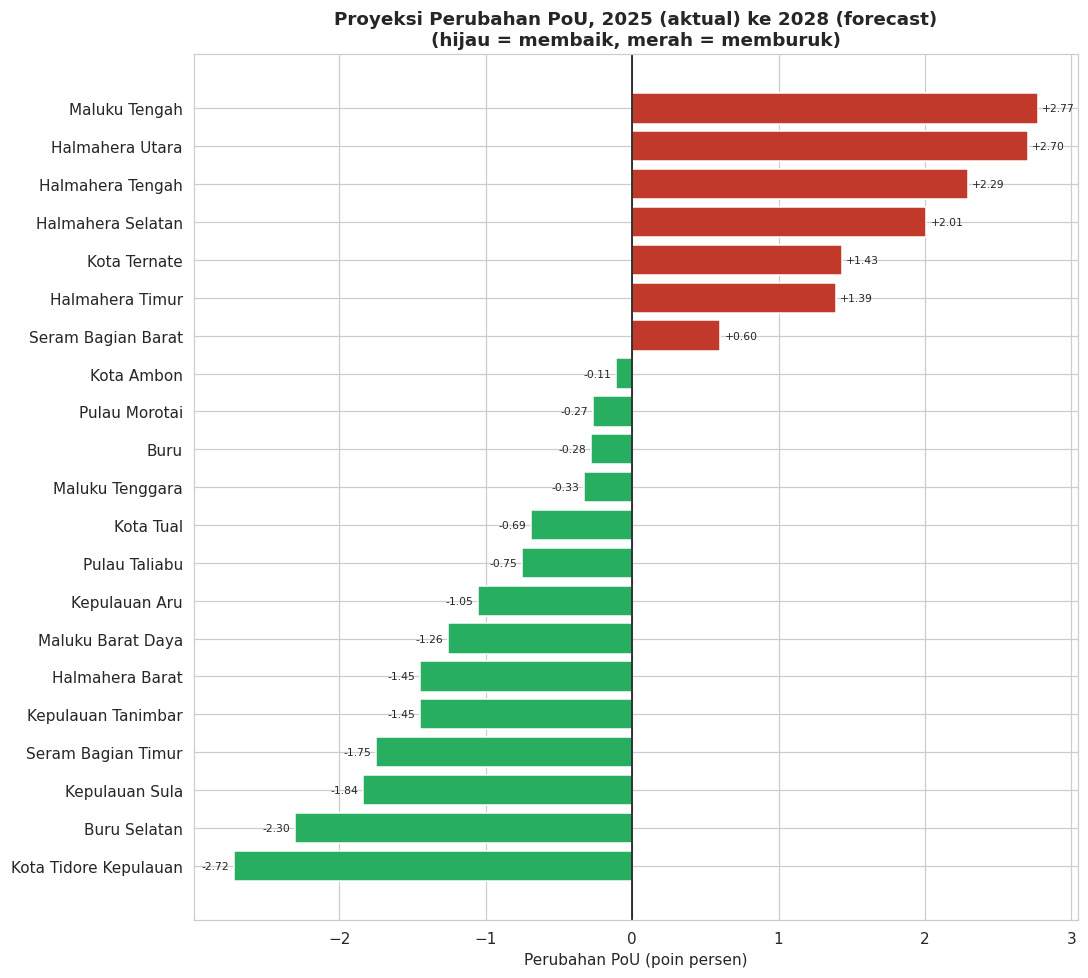

In [21]:
change_2025_2028 = []
for kab in kab_list:
    pou_2025_val = df[(df["Kab/Kota"] == kab) & (df["Tahun"] == 2025)]["Y_PoU"].values[0]
    fc_2028_val = forecast_df[(forecast_df["Kab_Kota"] == kab) & (forecast_df["Tahun"] == 2028)]["Forecast_PoU"].values[0]
    change_2025_2028.append({
        "Kab_Kota": kab, "PoU_2025": round(pou_2025_val, 2), "Forecast_2028": round(fc_2028_val, 2),
        "Perubahan": round(fc_2028_val - pou_2025_val, 2)
    })

change_df = pd.DataFrame(change_2025_2028).sort_values("Perubahan")
print("Kabupaten/kota dengan proyeksi PERBAIKAN terbesar (PoU turun paling banyak), 2025->2028:")
print(change_df.head(5).to_string(index=False))
print()
print("Kabupaten/kota dengan proyeksi PEMBURUKAN terbesar (PoU naik paling banyak), 2025->2028:")
print(change_df.tail(5).sort_values("Perubahan", ascending=False).to_string(index=False))
change_df.to_csv(os.path.join(TABLE_DIR, "perubahan_2025_2028.csv"), index=False)

fig, ax = plt.subplots(figsize=(10, 9))
plot_change = change_df.sort_values("Perubahan")
colors_bar = ["#27ae60" if v < 0 else "#c0392b" for v in plot_change["Perubahan"]]
bars = ax.barh(plot_change["Kab_Kota"].str.split(" \(").str[0], plot_change["Perubahan"], color=colors_bar)
ax.bar_label(bars, fmt="%+.2f", fontsize=7, padding=3)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Proyeksi Perubahan PoU, 2025 (aktual) ke 2028 (forecast)\n(hijau = membaik, merah = memburuk)")
ax.set_xlabel("Perubahan PoU (poin persen)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "08_perubahan_2025_2028.png"), dpi=150, bbox_inches="tight")
plt.show()

### 11.2 Forecast Agregat Tingkat Provinsi

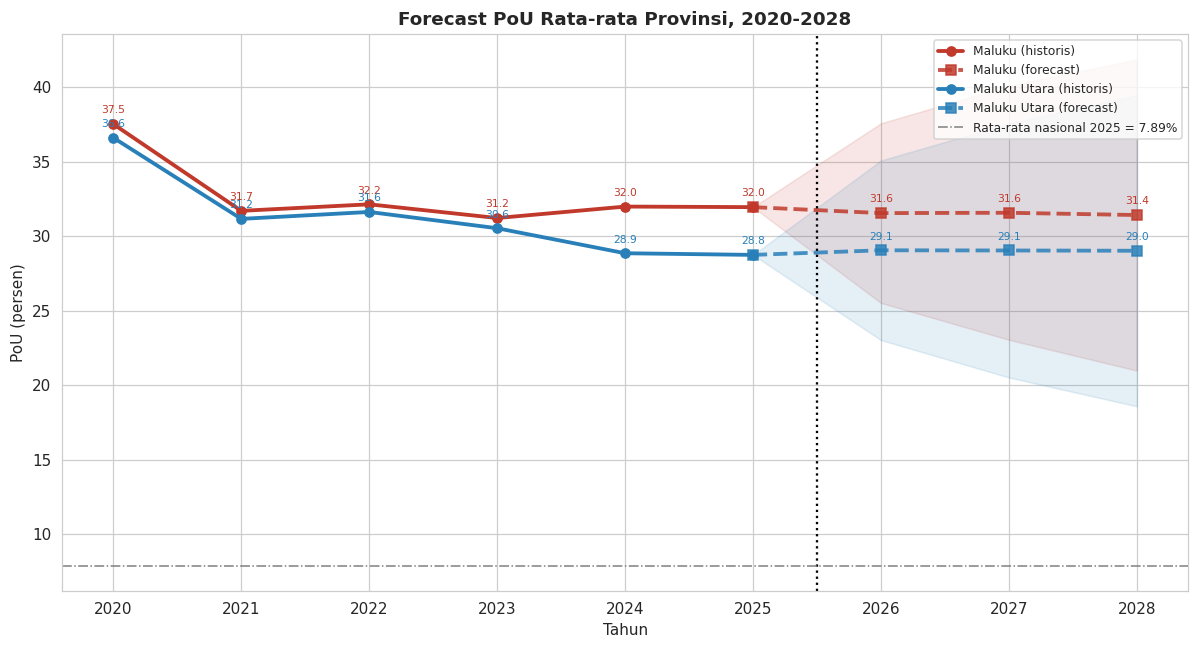

In [22]:
prov_hist = df.groupby(["Provinsi", "Tahun"])["Y_PoU"].mean().reset_index()
prov_fc = forecast_df.groupby(["Provinsi", "Tahun"])["Forecast_PoU"].mean().reset_index()
prov_fc_lower = forecast_df.groupby(["Provinsi", "Tahun"])["CI_Lower_95"].mean().reset_index()
prov_fc_upper = forecast_df.groupby(["Provinsi", "Tahun"])["CI_Upper_95"].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 6))
prov_colors = {"Maluku": "#c0392b", "Maluku Utara": "#2980b9"}
for prov, color in prov_colors.items():
    hist_sub = prov_hist[prov_hist["Provinsi"] == prov].sort_values("Tahun")
    fc_sub = prov_fc[prov_fc["Provinsi"] == prov].sort_values("Tahun")
    fc_lower = prov_fc_lower[prov_fc_lower["Provinsi"] == prov].sort_values("Tahun")["CI_Lower_95"].values
    fc_upper = prov_fc_upper[prov_fc_upper["Provinsi"] == prov].sort_values("Tahun")["CI_Upper_95"].values
    ax.plot(hist_sub["Tahun"], hist_sub["Y_PoU"], marker="o", linewidth=2.5, color=color, label=f"{prov} (historis)")
    connect_years = [2025] + fc_sub["Tahun"].tolist()
    connect_vals = [hist_sub["Y_PoU"].iloc[-1]] + fc_sub["Forecast_PoU"].tolist()
    ax.plot(connect_years, connect_vals, marker="s", linestyle="--", linewidth=2.5, color=color,
            alpha=0.85, label=f"{prov} (forecast)")
    ax.fill_between(connect_years, [hist_sub["Y_PoU"].iloc[-1]] + list(fc_lower),
                     [hist_sub["Y_PoU"].iloc[-1]] + list(fc_upper), color=color, alpha=0.12)
    for yr, val in zip(hist_sub["Tahun"], hist_sub["Y_PoU"]):
        ax.annotate(f"{val:.1f}", xy=(yr, val), xytext=(0, 7), textcoords="offset points", ha="center", fontsize=7, color=color)
    for yr, val in zip(fc_sub["Tahun"], fc_sub["Forecast_PoU"]):
        ax.annotate(f"{val:.1f}", xy=(yr, val), xytext=(0, 7), textcoords="offset points", ha="center", fontsize=7, color=color)

ax.axvline(2025.5, color="black", linestyle=":", linewidth=1.5)
ax.axhline(7.89, color="gray", linestyle="-.", linewidth=1, label="Rata-rata nasional 2025 = 7.89%")
ax.set_title("Forecast PoU Rata-rata Provinsi, 2020-2028")
ax.set_xlabel("Tahun")
ax.set_ylabel("PoU (persen)")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "09_forecast_provinsi.png"), dpi=150, bbox_inches="tight")
plt.show()

### 11.3 Pergeseran Peringkat: 2025 vs Forecast 2028

Perbandingan peringkat kerawanan PoU, 2025 vs forecast 2028 (peringkat 1 = PoU tertinggi/paling rawan):
                                            PoU_2025  Peringkat_2025  Forecast_PoU_2028  Peringkat_2028  Perubahan_Peringkat
Kepulauan Sula                                 37.36               1             35.522               1                    0
Buru Selatan                                   36.17               2             33.875               4                   -2
Halmahera Barat                                36.09               3             34.639               2                    1
Kepulauan Tanimbar (Maluku Tenggara Barat)     35.76               4             34.308               3                    1
Pulau Taliabu                                  34.19               5             33.438               6                   -1
Seram Bagian Timur                             33.63               6             31.885              10                   -4
Kepulauan Aru        

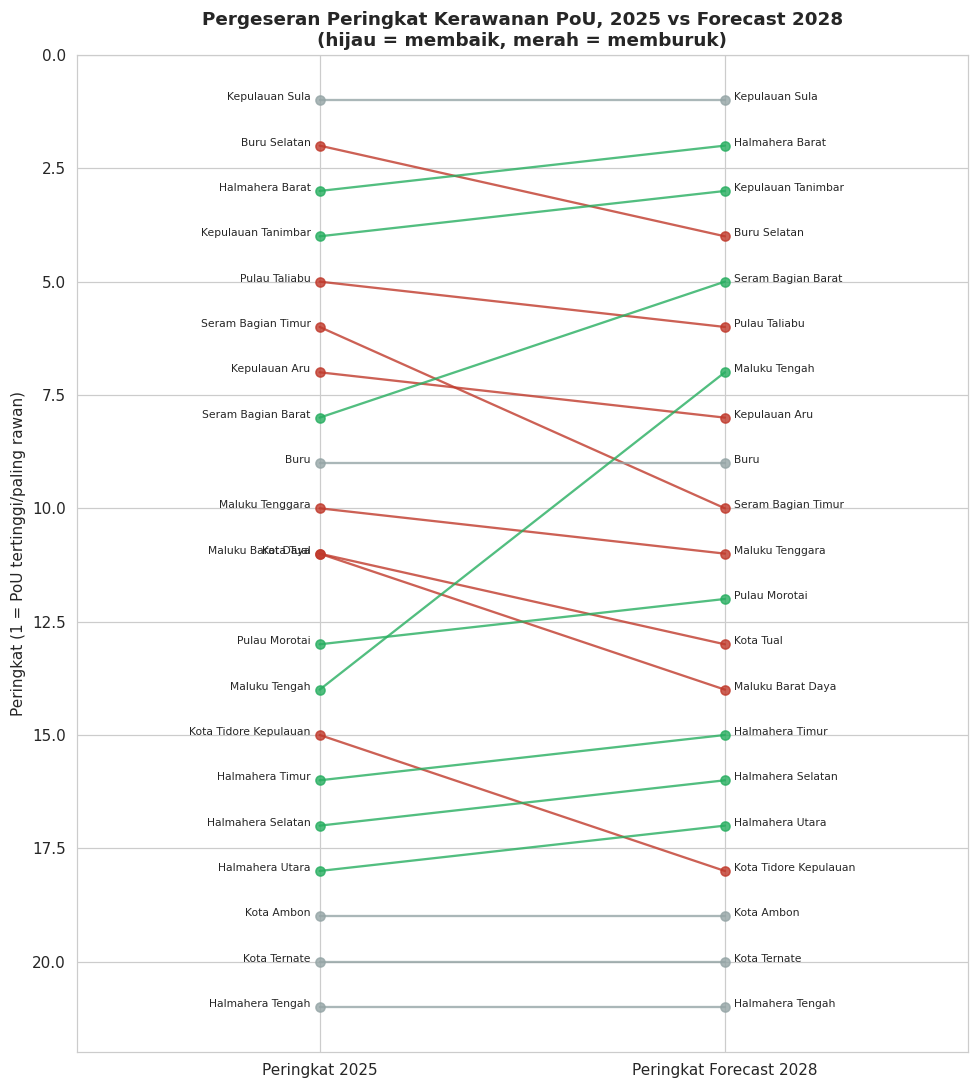

In [23]:
rank_2025 = pou_2025.rank(ascending=False).astype(int)
forecast_2028 = forecast_df[forecast_df["Tahun"] == 2028].set_index("Kab_Kota")["Forecast_PoU"]
rank_2028 = forecast_2028.rank(ascending=False).astype(int)

rank_comparison = pd.DataFrame({
    "PoU_2025": pou_2025, "Peringkat_2025": rank_2025,
    "Forecast_PoU_2028": forecast_2028, "Peringkat_2028": rank_2028,
}).sort_values("Peringkat_2025")
rank_comparison["Perubahan_Peringkat"] = rank_comparison["Peringkat_2025"] - rank_comparison["Peringkat_2028"]

print("Perbandingan peringkat kerawanan PoU, 2025 vs forecast 2028 (peringkat 1 = PoU tertinggi/paling rawan):")
print(rank_comparison.to_string())
rank_comparison.to_csv(os.path.join(TABLE_DIR, "perbandingan_peringkat_2025_2028.csv"))

fig, ax = plt.subplots(figsize=(9, 10))
for kab, row in rank_comparison.iterrows():
    color = "#c0392b" if row["Perubahan_Peringkat"] < 0 else ("#27ae60" if row["Perubahan_Peringkat"] > 0 else "#95a5a6")
    ax.plot([0, 1], [row["Peringkat_2025"], row["Peringkat_2028"]], marker="o", color=color, linewidth=1.5, alpha=0.8)
    ax.annotate(kab.split(" (")[0], xy=(0, row["Peringkat_2025"]), xytext=(-6, 0),
                 textcoords="offset points", ha="right", fontsize=7)
    ax.annotate(kab.split(" (")[0], xy=(1, row["Peringkat_2028"]), xytext=(6, 0),
                 textcoords="offset points", ha="left", fontsize=7)

ax.set_xlim(-0.6, 1.6)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Peringkat 2025", "Peringkat Forecast 2028"], fontsize=10)
ax.invert_yaxis()
ax.set_ylabel("Peringkat (1 = PoU tertinggi/paling rawan)")
ax.set_title("Pergeseran Peringkat Kerawanan PoU, 2025 vs Forecast 2028\n(hijau = membaik, merah = memburuk)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "10_slope_chart_peringkat.png"), dpi=150, bbox_inches="tight")
plt.show()

### 11.4 Peta Forecast PoU 2028 (Bonus)

In [24]:
import requests
from shapely.geometry import shape as shapely_shape
try:
    import geopandas as gpd
    GEOPANDAS_OK = True
except ImportError:
    GEOPANDAS_OK = False

centroid_lookup = {
    "Kepulauan Tanimbar (Maluku Tenggara Barat)": (-7.61186, 131.38000),
    "Maluku Tenggara": (-5.75000, 132.73334), "Maluku Tengah": (-3.29167, 128.96750),
    "Buru": (-3.32767, 126.68413), "Kepulauan Aru": (-6.17059, 134.46991),
    "Seram Bagian Barat": (-3.10270, 128.42996), "Seram Bagian Timur": (-3.39851, 130.39166),
    "Maluku Barat Daya": (-7.82960, 126.17386), "Buru Selatan": (-3.52187, 126.59271),
    "Kota Ambon": (-3.70000, 128.18333), "Kota Tual": (-5.64301, 132.74934),
    "Halmahera Barat": (1.41709, 127.55264), "Halmahera Tengah": (0.48056, 128.25000),
    "Kepulauan Sula": (-1.86460, 125.69046), "Halmahera Selatan": (-0.39550, 127.90833),
    "Halmahera Utara": (1.73194, 128.00778), "Halmahera Timur": (1.33517, 128.48627),
    "Pulau Morotai": (2.19924, 128.40546), "Pulau Taliabu": (-1.84578, 124.78992),
    "Kota Ternate": (0.89618, 127.31016), "Kota Tidore Kepulauan": (0.60962, 127.56981),
}
direct_file_map = {
    "Kepulauan Tanimbar (Maluku Tenggara Barat)": "Maluku/Kabupaten-Kota/Maluku Tenggara Barat/Maluku Tenggara Barat.geojson",
    "Maluku Tenggara": "Maluku/Kabupaten-Kota/Maluku Tenggara/Maluku Tenggara.geojson",
    "Maluku Tengah": "Maluku/Kabupaten-Kota/Maluku Tengah/Maluku Tengah.geojson",
    "Buru": "Maluku/Kabupaten-Kota/Buru/Buru.geojson",
    "Kepulauan Aru": "Maluku/Kabupaten-Kota/Kepulauan Aru/Kepulauan Aru.geojson",
    "Seram Bagian Barat": "Maluku/Kabupaten-Kota/Seram Bagian Barat/Seram Bagian Barat.geojson",
    "Seram Bagian Timur": "Maluku/Kabupaten-Kota/Seram Bagian Timur/Seram Bagian Timur.geojson",
    "Maluku Barat Daya": "Maluku/Kabupaten-Kota/Maluku Barat Daya/Maluku Barat Daya.geojson",
    "Buru Selatan": "Maluku/Kabupaten-Kota/Buru Selatan/Buru Selatan.geojson",
    "Kota Ambon": "Maluku/Kabupaten-Kota/Ambon/Ambon.geojson",
    "Kota Tual": "Maluku/Kabupaten-Kota/Tual/Tual.geojson",
    "Halmahera Barat": "Maluku Utara/Kabupaten-Kota/Halmahera Barat/Halmahera Barat.geojson",
    "Halmahera Tengah": "Maluku Utara/Kabupaten-Kota/Halmahera Tengah/Halmahera Tengah.geojson",
    "Kepulauan Sula": "Maluku Utara/Kabupaten-Kota/Kepulauan Sula/Kepulauan Sula.geojson",
    "Halmahera Selatan": "Maluku Utara/Kabupaten-Kota/Halmahera Selatan/Halmahera Selatan.geojson",
    "Halmahera Utara": "Maluku Utara/Kabupaten-Kota/Halmahera Utara/Halmahera Utara.geojson",
    "Halmahera Timur": "Maluku Utara/Kabupaten-Kota/Halmahera Timur/Halmahera Timur.geojson",
    "Pulau Morotai": "Maluku Utara/Kabupaten-Kota/Pulau Morotai/Pulau Morotai.geojson",
    "Kota Ternate": "Maluku Utara/Kabupaten-Kota/Ternate/Ternate.geojson",
    "Kota Tidore Kepulauan": "Maluku Utara/Kabupaten-Kota/Tidore Kepulauan/Tidore Kepulauan.geojson",
}
GITHUB_GEOJSON_BASE = "https://raw.githubusercontent.com/mahendrayudha/indonesia-geojson/main/"

polygons_available = False
gdf_polygons = None
if GEOPANDAS_OK:
    try:
        matched_rows = []
        for kab, relpath in direct_file_map.items():
            url = GITHUB_GEOJSON_BASE + urllib.parse.quote(relpath)
            r = requests.get(url, timeout=30)
            r.raise_for_status()
            gj = r.json()
            geom = shapely_shape(gj["features"][0]["geometry"])
            matched_rows.append({"Kab_Kota": kab, "geometry": geom})
        if len(matched_rows) >= 18:
            gdf_polygons = gpd.GeoDataFrame(matched_rows, geometry="geometry", crs="EPSG:4326")
            polygons_available = True
            print(f"Berhasil mengunduh {len(matched_rows)} dari 21 poligon untuk peta forecast 2028.")
    except Exception as err:
        print("Unduhan poligon gagal:", repr(err))
if not polygons_available:
    print("Poligon tidak tersedia, memakai mode peta gelembung berbasis titik centroid.")

Berhasil mengunduh 20 dari 21 poligon untuk peta forecast 2028.


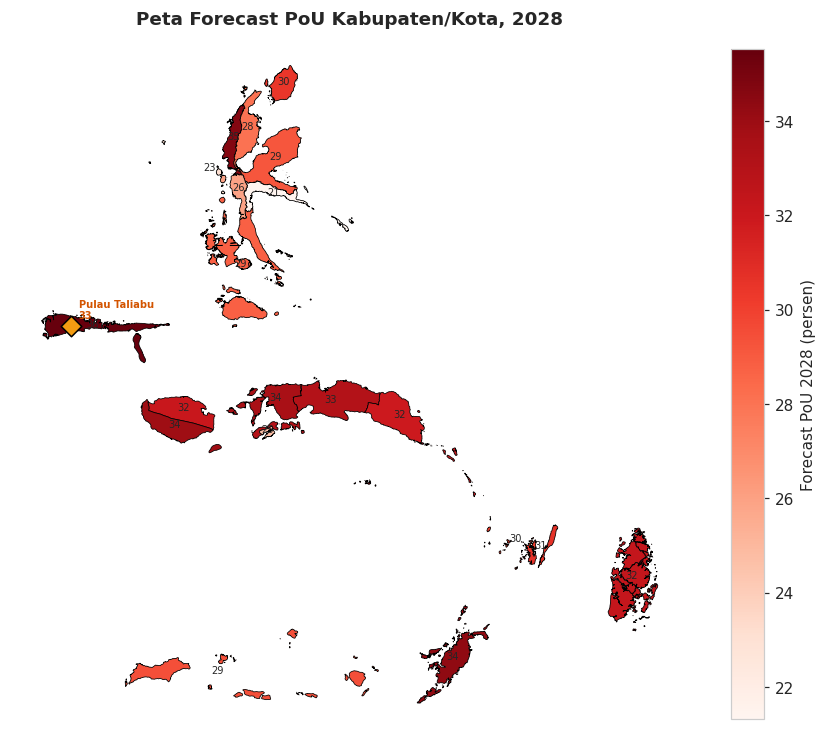

In [25]:
forecast_2028_df = forecast_df[forecast_df["Tahun"] == 2028][["Kab_Kota", "Forecast_PoU"]]

if polygons_available:
    gdf_fc = gdf_polygons.merge(forecast_2028_df, on="Kab_Kota", how="left")
    missing_units = [k for k in centroid_lookup if k not in set(gdf_polygons["Kab_Kota"])]
    fig, ax = plt.subplots(figsize=(8, 9))
    gdf_fc.plot(column="Forecast_PoU", cmap="Reds", edgecolor="black", linewidth=0.5,
                legend=True, ax=ax, legend_kwds={"label": "Forecast PoU 2028 (persen)", "shrink": 0.7})
    for _, row in gdf_fc.iterrows():
        c = row.geometry.centroid
        ax.annotate(f"{row['Forecast_PoU']:.0f}", xy=(c.x, c.y), ha="center", fontsize=6.5)
    for kab in missing_units:
        lat, lon = centroid_lookup[kab]
        val = forecast_2028_df.set_index("Kab_Kota").loc[kab, "Forecast_PoU"]
        ax.scatter([lon], [lat], color="#f39c12", s=90, edgecolor="black", zorder=5, marker="D")
        ax.annotate(f"{kab.split(' (')[0]}\n{val:.0f}", xy=(lon, lat), xytext=(5, 5),
                     textcoords="offset points", fontsize=6.5, fontweight="bold", color="#d35400")
    ax.set_title("Peta Forecast PoU Kabupaten/Kota, 2028")
    ax.set_axis_off()
    fig_name = "11_peta_forecast_2028.png"
else:
    fig, ax = plt.subplots(figsize=(8, 9))
    vals = forecast_2028_df.set_index("Kab_Kota")["Forecast_PoU"]
    norm = plt.Normalize(vals.min(), vals.max())
    cmap = plt.cm.Reds
    for kab, val in vals.items():
        lat, lon = centroid_lookup[kab]
        ax.scatter([lon], [lat], s=280, color=cmap(norm(val)), edgecolor="black", linewidth=0.6, zorder=3)
        ax.annotate(f"{kab.split(' (')[0]}\n{val:.0f}", xy=(lon, lat), ha="center", va="center", fontsize=6)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, shrink=0.7, label="Forecast PoU 2028 (persen)")
    ax.set_title("Peta Gelembung Forecast PoU 2028 (mode fallback)")
    ax.set_axis_off()
    fig_name = "11_bubble_forecast_2028_fallback.png"

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, fig_name), dpi=150, bbox_inches="tight")
plt.show()

## 12. Sintesis dan Insight Utama

In [26]:
print("=" * 72)
print("RINGKASAN TEMUAN FORECASTING PoU 2026-2028, KEPULAUAN MALUKU")
print("=" * 72)
print()
print(f"1. Model terpilih: {best_model_name} (MAE backtesting={best_model_mae:.3f} poin persen), dipilih "
      "lewat perbandingan dengan ElasticNet menggunakan fitur panel yang identik. Konfigurasi sengaja "
      "dibatasi pada kedalaman pohon minimal 2 untuk menghindari forecast yang seragam/flat antar "
      "kabupaten/kota -- masalah yang muncul pada konfigurasi terlalu dangkal meski MAE backtesting-nya "
      "sedikit lebih rendah.")
print()
print(f"2. Faktor paling dominan dalam model (feature importance): '{top_driver}' "
      f"({importance_df.iloc[0]['Importance_Persen']:.1f} persen), diikuti "
      f"'{importance_df.iloc[1]['Label']}' ({importance_df.iloc[1]['Importance_Persen']:.1f} persen). "
      "Dominasi karakteristik dasar kabupaten/kota dan nilai tahun sebelumnya menunjukkan posisi relatif "
      "tiap wilayah (struktural) jauh lebih menentukan PoU dibanding faktor tunggal tahun berjalan.")
print()
avg_fc_2028 = forecast_df[forecast_df["Tahun"]==2028]["Forecast_PoU"].mean()
avg_actual_2025 = df[df["Tahun"]==2025]["Y_PoU"].mean()
print(f"3. Rata-rata PoU 21 kabupaten/kota: {avg_actual_2025:.2f} persen (2025) menjadi "
      f"{avg_fc_2028:.2f} persen (2028, forecast), masih {avg_fc_2028/7.89:.1f} kali rata-rata nasional.")
print()
best_improve = change_df.iloc[0]
worst_decline = change_df.iloc[-1]
print(f"4. Proyeksi PERBAIKAN terbesar: {best_improve['Kab_Kota']} ({best_improve['Perubahan']:+.2f} poin persen).")
print(f"   Proyeksi PEMBURUKAN terbesar: {worst_decline['Kab_Kota']} ({worst_decline['Perubahan']:+.2f} poin persen).")
print()
print(f"5. Paradoks Produksi #1: {paradox_kab} (residual {paradox_residual:+.2f} poin persen) -- "
      "kapasitas produksi tidak sejalan dengan PoU rendah, bukti kuantitatif hipotesis paradoks distribusi.")
print(f"   Underdog Ketahanan Pangan #1: {underdog_kab} (residual {underdog_residual:+.2f} poin persen) -- "
      "kandidat praktik baik untuk direplikasi.")
print()
n_improve = (rank_comparison["Perubahan_Peringkat"] > 0).sum()
n_worsen = (rank_comparison["Perubahan_Peringkat"] < 0).sum()
print(f"6. Proyeksi pergeseran peringkat 2025->2028: {n_improve} kabupaten/kota membaik posisi relatif, "
      f"{n_worsen} memburuk.")

RINGKASAN TEMUAN FORECASTING PoU 2026-2028, KEPULAUAN MALUKU

1. Model terpilih: XGBoost (Panel, Ditala) (MAE backtesting=2.245 poin persen), dipilih lewat perbandingan dengan ElasticNet menggunakan fitur panel yang identik. Konfigurasi sengaja dibatasi pada kedalaman pohon minimal 2 untuk menghindari forecast yang seragam/flat antar kabupaten/kota -- masalah yang muncul pada konfigurasi terlalu dangkal meski MAE backtesting-nya sedikit lebih rendah.

2. Faktor paling dominan dalam model (feature importance): 'Karakteristik Dasar Kabupaten/Kota (rata-rata historis)' (43.2 persen), diikuti 'PoU Tahun Sebelumnya' (18.6 persen). Dominasi karakteristik dasar kabupaten/kota dan nilai tahun sebelumnya menunjukkan posisi relatif tiap wilayah (struktural) jauh lebih menentukan PoU dibanding faktor tunggal tahun berjalan.

3. Rata-rata PoU 21 kabupaten/kota: 30.44 persen (2025) menjadi 30.30 persen (2028, forecast), masih 3.8 kali rata-rata nasional.

4. Proyeksi PERBAIKAN terbesar: Kota Tidore

## 13. Ekspor Hasil dan Pembuatan Dokumen RAG

In [27]:
rag_lines = []
rag_lines.append("# Dokumen Referensi: Forecasting PoU 2026-2028 Kepulauan Maluku (Model XGBoost)")
rag_lines.append("")
rag_lines.append("## Ringkasan Proyek")
rag_lines.append(
    "Proyek GEMASTIK XIX/2026 (Divisi Data Mining) meramalkan Prevalensi Ketidakcukupan Konsumsi Pangan "
    "(PoU) 2026-2028 untuk 21 kabupaten/kota di Provinsi Maluku dan Maluku Utara berbasis data 2020-2025, "
    "dilengkapi analisis Paradoks Produksi dan Underdog Ketahanan Pangan."
)
rag_lines.append("")
rag_lines.append("## Metodologi Forecasting")
rag_lines.append(
    "- Model panel (menggabungkan seluruh 21 kabupaten/kota x tahun menjadi satu dataset 126 baris) "
    "dipilih dibanding model univariat per kabupaten/kota, karena tiap unit hanya memiliki 6 observasi "
    "tahunan -- terlalu sedikit untuk deret waktu klasik. Fitur: lag PoU, target encoding karakteristik "
    "dasar kabupaten/kota (kab_hist_mean), Indeks Kapasitas Pangan, kemiskinan, PDRB, kepadatan, IPM, "
    "pangsa pengeluaran pangan, dan tahun."
)
rag_lines.append(
    f"- Dua model dibandingkan lewat backtesting walk-forward (latih 2021-2023, uji rekursif 2024-2025): "
    f"ElasticNet dan XGBoost. Model terpilih: {best_model_name} (MAE backtesting={best_model_mae:.3f})."
)
rag_lines.append(
    "- Kedalaman pohon XGBoost sengaja dibatasi minimal 2 (bukan 1) pada grid search, karena percobaan "
    "awal menunjukkan pohon terlalu dangkal dengan one-hot encoding kabupaten/kota menghasilkan forecast "
    "yang identik/flat antar banyak unit -- meski MAE backtesting sedikit lebih rendah, hasil tersebut "
    "kurang informatif. Target encoding (kab_hist_mean) menggantikan one-hot encoding untuk memampatkan "
    "informasi identitas kabupaten/kota menjadi satu fitur kontinu."
)
rag_lines.append(
    "- Fitur eksogen untuk 2026-2028 (kemiskinan, PDRB, kepadatan, kapasitas produksi, IPM, pangsa "
    "pengeluaran pangan) ditahan konstan pada nilai 2025 (asumsi ceteris paribus) karena nilai masa depan "
    "belum tersedia."
)
rag_lines.append("")
rag_lines.append("## Insight Model (Feature Importance)")
for _, row in importance_df.iterrows():
    rag_lines.append(f"- {row['Label']}: {row['Importance_Persen']:.1f} persen kontribusi terhadap model.")
rag_lines.append("")
rag_lines.append("## Definisi Paradoks dan Underdog")
rag_lines.append(
    "- PoU diregresikan pooled terhadap Indeks Kapasitas Pangan Lokal (126 observasi). Residual rata-rata "
    "per kabupaten/kota (2020-2025): residual positif besar = Paradoks (kapasitas tinggi, PoU tetap "
    "tinggi); residual negatif besar = Underdog (kapasitas rendah, PoU berhasil ditekan)."
)
rag_lines.append("")
rag_lines.append("## Temuan Kunci")
rag_lines.append(f"- Rata-rata PoU: {avg_actual_2025:.2f} persen (2025) menjadi {avg_fc_2028:.2f} persen (2028, forecast).")
rag_lines.append(f"- Faktor paling dominan: {top_driver} ({importance_df.iloc[0]['Importance_Persen']:.1f} persen).")
rag_lines.append(f"- Proyeksi perbaikan terbesar: {best_improve['Kab_Kota']} ({best_improve['Perubahan']:+.2f} poin persen).")
rag_lines.append(f"- Proyeksi pemburukan terbesar: {worst_decline['Kab_Kota']} ({worst_decline['Perubahan']:+.2f} poin persen).")
rag_lines.append(f"- Paradoks Produksi #1: {paradox_kab} (residual {paradox_residual:+.2f}).")
rag_lines.append(f"- Underdog Ketahanan Pangan #1: {underdog_kab} (residual {underdog_residual:+.2f}).")
rag_lines.append(f"- Top-1 PoU tertinggi 2025: {top1_kab} ({pou_2025[top1_kab]:.2f} persen).")
rag_lines.append(f"- Bottom-1 PoU terendah 2025: {bottom1_kab} ({pou_2025[bottom1_kab]:.2f} persen).")
rag_lines.append("")
rag_lines.append("## Keterbatasan")
rag_lines.append(
    "- Forecast berbasis 6 titik data historis per unit; sebaiknya diperbarui tiap kali data tahun baru "
    "tersedia, tidak dipakai untuk horizon lebih dari 3 tahun tanpa evaluasi ulang."
)
rag_lines.append(
    "- Fitur eksogen 2026-2028 memakai asumsi ceteris paribus (nilai 2025 ditahan konstan); forecast akan "
    "lebih akurat jika data eksogen tahun berjalan tersedia dan dimasukkan ulang."
)
rag_lines.append(
    "- Analisis Paradoks/Underdog memakai satu proksi kapasitas (produksi perikanan); R-squared regresi "
    "pooled rendah sehingga interpretasi kausal harus tetap berhati-hati."
)

rag_text = "\n".join(rag_lines)
rag_path = os.path.join(OUTPUT_DIR, "dokumen_rag_forecasting.md")
with open(rag_path, "w", encoding="utf-8") as f:
    f.write(rag_text)

print("Dokumen RAG berhasil dibuat:", rag_path)
print()
print(rag_text)

Dokumen RAG berhasil dibuat: gemastik_forecast_output/dokumen_rag_forecasting.md

# Dokumen Referensi: Forecasting PoU 2026-2028 Kepulauan Maluku (Model XGBoost)

## Ringkasan Proyek
Proyek GEMASTIK XIX/2026 (Divisi Data Mining) meramalkan Prevalensi Ketidakcukupan Konsumsi Pangan (PoU) 2026-2028 untuk 21 kabupaten/kota di Provinsi Maluku dan Maluku Utara berbasis data 2020-2025, dilengkapi analisis Paradoks Produksi dan Underdog Ketahanan Pangan.

## Metodologi Forecasting
- Model panel (menggabungkan seluruh 21 kabupaten/kota x tahun menjadi satu dataset 126 baris) dipilih dibanding model univariat per kabupaten/kota, karena tiap unit hanya memiliki 6 observasi tahunan -- terlalu sedikit untuk deret waktu klasik. Fitur: lag PoU, target encoding karakteristik dasar kabupaten/kota (kab_hist_mean), Indeks Kapasitas Pangan, kemiskinan, PDRB, kepadatan, IPM, pangsa pengeluaran pangan, dan tahun.
- Dua model dibandingkan lewat backtesting walk-forward (latih 2021-2023, uji rekursif 2024-20

In [28]:
zip_path = os.path.join(".", "gemastik_hasil_forecasting.zip")
if os.path.exists(zip_path):
    os.remove(zip_path)

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk(OUTPUT_DIR):
        for file in files:
            full_path = os.path.join(root, file)
            arcname = os.path.relpath(full_path, OUTPUT_DIR)
            zf.write(full_path, arcname)

zip_size_mb = os.path.getsize(zip_path) / (1024 * 1024)
print(f"Seluruh hasil berhasil dikemas ke: {zip_path} ({zip_size_mb:.2f} MB)")

with zipfile.ZipFile(zip_path, "r") as zf:
    print()
    print("Isi berkas zip:")
    for name in sorted(zf.namelist()):
        print(" -", name)

if IN_COLAB:
    from google.colab import files
    files.download(zip_path)
    print()
    print("Unduhan otomatis dimulai.")
else:
    print()
    print("Dijalankan di luar Google Colab: unduh manual berkas zip di atas dari direktori kerja.")

Seluruh hasil berhasil dikemas ke: ./gemastik_hasil_forecasting.zip (1.73 MB)

Isi berkas zip:
 - dokumen_rag_forecasting.md
 - figures/01_historis_semua_kabkota.png
 - figures/03_perbandingan_model.png
 - figures/04_feature_importance.png
 - figures/05_forecast_small_multiples.png
 - figures/06_scatter_paradoks_underdog.png
 - figures/07_visualisasi_utama_4unit.png
 - figures/08_perubahan_2025_2028.png
 - figures/09_forecast_provinsi.png
 - figures/10_slope_chart_peringkat.png
 - figures/11_peta_forecast_2028.png
 - tables/dataset_bersih_forecasting.csv
 - tables/feature_importance.csv
 - tables/forecast_pou_2026_2028.csv
 - tables/paradoks_underdog_ranking.csv
 - tables/perbandingan_model.csv
 - tables/perbandingan_peringkat_2025_2028.csv
 - tables/perubahan_2025_2028.csv
 - tables/statistik_pertumbuhan_volatilitas.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Unduhan otomatis dimulai.


## Penutup

Notebook ini menyelesaikan alur forecasting PoU berbasis satu model utama (XGBoost panel, dipilih lewat
perbandingan dengan ElasticNet), digali secara maksimal: feature importance untuk insight kebijakan,
forecast 2026-2028 yang benar-benar terdiferensiasi antar kabupaten/kota (bukan flat), analisis Paradoks
Produksi dan Underdog Ketahanan Pangan berbasis regresi residual, visualisasi utama empat kabupaten/kota
kunci (historis + forecast dengan garis batas), insight tambahan (perubahan terbesar, agregat provinsi,
pergeseran peringkat, peta forecast 2028), hingga dokumen RAG dan ekspor hasil siap unduh.